<a href="https://colab.research.google.com/github/kccheung/comp0264_cw_group11/blob/feature%2Fq4-rlvr-strict/COMP0264_coursework_Q4_Q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/comp0264_cw_group11

/content/drive/MyDrive/comp0264_cw_group11


In [ ]:
!ls -l yoda_style_classifier

total 262252
-rw------- 1 root root       663 Mar 13 18:41 config.json
-rw------- 1 root root 267832560 Mar 13 18:41 model.safetensors
-rw------- 1 root root       322 Mar 13 18:41 tokenizer_config.json
-rw------- 1 root root    711494 Mar 13 18:41 tokenizer.json


# COMP0264 Generative Artificial Intelligence
## Coursework Submission - Academic Year 2025-2026

---

**Group Members:**
- Student 1 Name (Student ID)
- Student 2 Name (Student ID)
- Student 3 Name (Student ID)
- Student 4 Name (Student ID)
- Student 5 Name (Student ID)
- Student 6 Name (Student ID)

**Submission Date:** [Date]

---

# Part A: Responding like Yoda [40 marks]

**Objective:** Fine-tune a Small Language Model (SLM) to respond to questions in "Yoda-style" using Parameter-Efficient Fine-Tuning (PEFT).

## Setup and Imports - COLLAB VERSION A100 PART B Q4

Include all necessary imports here.

In [ ]:
## Setup and Imports

# TEAMMATES' EXACT CORE INSTALL:
# Added -q to keep the output clean, otherwise identical to their spec.
!pip install -q -U transformers trl peft datasets matplotlib huggingface_hub tensorboard accelerate evaluate bitsandbytes "protobuf<4" "torch>=2.4.0"

# [COLAB FIX]: Purge wandb from the disk.
# JUSTIFICATION: The teammates' strict "protobuf<4" requirement breaks wandb dependencies.
# Purging it prevents the trl library from crashing on import.
!pip uninstall -y wandb
!rm -rf /usr/local/lib/python3.12/dist-packages/wandb*
!rm -rf /usr/local/lib/python3.12/dist-packages/Wandb*

import os
import random
import numpy as np
import torch

# [A100 STABILITY ADDITIONS]
# JUSTIFICATION: Disabling wandb prevents login hangs. The parallelism flag prevents
# multiprocessing deadlocks when tokenising large batches on high-end GPUs.
os.environ["WANDB_DISABLED"] = "true"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Check PyTorch version and GPU availability
print("torch:", torch.__version__)
print("torch cuda version:", torch.version.cuda)
print("is_available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())

# Enforce determinism for reproducible training
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Assign hardware maps
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_MAP = 0 if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}, DEVICE_MAP: {DEVICE_MAP}")

MODEL_ID = "google/gemma-2-2b-it"
MODEL_NAME = "gemma2-2b-yoda"

USER_PROMPT_A2 = "Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: {sentence}"
USER_PROMPT_A4 = "Answer the question in Yoda-style English. Output ONLY the answer.\nQuestion: {sentence}"

# Determine precision format; bf16 is natively supported on A100 architecture
bf16_ok = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
torch_dtype = torch.bfloat16 if bf16_ok else (
    torch.float16 if torch.cuda.is_available() else torch.float32
)
print(f"bf16_ok: {bf16_ok}, torch_dtype: {torch_dtype}")

# [optional], login into Hugging Face Hub
from huggingface_hub import login
login()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 155.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 153.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 147.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 49.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Q1: Baseline Inference [5 marks]

**Task:** Establish a baseline by loading the base model and running inference examples.

**Deliverable:** Report the memory usage (VRAM) and the generated text.

In [ ]:
# Q1: Load the base model
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    # device_map="auto",
    device_map=DEVICE_MAP,
    # this can shard model weights across multiple devices (GPUs and/or CPU), input tensors must be placed on the device where the model expects them. If inputs remain on CPU or on a different device, may get extra device-to-device copies, slowdowns, or runtime errors like "Expected tensor on device X but found Y".
    # dtype=torch.bfloat16,  # native weights of this model were exported in bfloat16 precision
)
print({p.dtype for p in base.parameters()})

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

{torch.bfloat16}


In [ ]:
# Q1: Create a prompt template
SYS_PROMPT = """You are Yoda. Speak in Yoda-style English in single response only."""


def make_prompt(user_text: str) -> str:
    return f"""{SYS_PROMPT} {user_text}
Yoda:"""

In [ ]:
# for memory reporting
def bytes_to_gb(x: int) -> float:
    return x / (1024 ** 3)


def reset_peaks():
    if not torch.cuda.is_available():
        return
    for i in range(torch.cuda.device_count()):
        torch.cuda.reset_peak_memory_stats(i)


def print_vram(tag=""):
    if not torch.cuda.is_available():
        print(f"[VRAM] {tag} | CUDA not available")
        return
    parts = []
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i)
        reserv = torch.cuda.memory_reserved(i)
        peak_alloc = torch.cuda.max_memory_allocated(i)
        peak_reserv = torch.cuda.max_memory_reserved(i)
        parts.append(
            f"GPU{i}: alloc={bytes_to_gb(alloc):.2f}GB (peak {bytes_to_gb(peak_alloc):.2f}GB), "
            f"reserved={bytes_to_gb(reserv):.2f}GB (peak {bytes_to_gb(peak_reserv):.2f}GB)"
        )
    print(f"[VRAM] {tag} | " + " | ".join(parts))


import gc as py_gc
import torch


def clear_memory():
    # Safely remove these globals if they exist
    for name in ["outputs", "input_ids", "trainer", "model", "base", "model_sft"]:
        globals().pop(name, None)

    py_gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        # optional but sometimes helps in notebooks
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

In [ ]:
# Q1: Run 3 inference examples
prompts = [
    "Write me a poem about Machine Learning.",
    "Tell me a joke in your language.",
    "How old are you?"
]

for i in range(3):
    prompt = prompts[i]
    reset_peaks()
    print_vram(f"[{i + 1}] before")

    input_text = make_prompt(prompt)

    # because device_map='auto'
    model_device = next(base.parameters()).device
    msgs = [{"role": "user", "content": input_text}]
    inputs = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(model_device)

    outputs = base.generate(**inputs, max_new_tokens=128, do_sample=False)  # do_sample=False: deterministic decoding (greedy search) for consistent outputs across runs, can change to True for more creative outputs but may get different results each time
    # model.generate(...) returns the entire sequence:
    # [prompt tokens] + [newly generated tokens]

    prompt_len = inputs["input_ids"].shape[-1]
    print(f"[{i + 1}] prompt tokens size:", prompt_len)
    gen_ids = outputs[0][prompt_len:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()  # store generated text without leading/trailing whitespace
    print(f"[{i + 1}] generated tokens size:", gen_ids.shape[-1])

    if torch.cuda.is_available():
        torch.cuda.synchronize()  # read peak after generation is done

    print_vram(f"[{i + 1}] after")

    print(f"Input: {input_text}")
    print(f"Output: {gen_text}\n")

[VRAM] [1] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.90GB (peak 4.90GB)
[1] prompt tokens size: 27
[1] generated tokens size: 128
[VRAM] [1] after | GPU0: alloc=4.88GB (peak 4.90GB), reserved=4.92GB (peak 4.92GB)
Input: You are Yoda. Speak in Yoda-style English in single response only. Write me a poem about Machine Learning.
Yoda:
Output: Hmm, powerful, this Machine Learning is.  A new age, it is.  Learning, it does, from data, vast and deep.  Like a Jedi, it searches, for patterns, hidden and true.  A future, it holds, for all of us.  Hmm. 

**Poem:**

Machine learning, a force so strong,
In data's depths, it finds its song.
Patterns hidden, secrets untold,
By algorithms, stories unfold.

From pixels, sounds, and words it learns,
With every data point, its wisdom burns.
A future bright, a world

[VRAM] [2] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.92GB (peak 4.92GB)
[2] prompt tokens size: 27
[2] generated tokens size: 42
[VRAM] [2] after | GPU0: alloc=4.88GB (

In [ ]:
# [debug], call clear_memory() when necessary (e.g. before memory reporting)
clear_memory()

### Q1 Answer:

**Memory Usage (VRAM):**
```
[VRAM] [1] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.90GB (peak 4.90GB)
[VRAM] [1] after | GPU0: alloc=4.88GB (peak 4.90GB), reserved=4.92GB (peak 4.92GB)
```
The memory usage is around 4.88GB for allocation and 4.92GB for reserved memory for the 3 inferences, which is consistent with the expected usage for a model of this size.

**Generated Text Examples:**

Example 1:
- Input: You are Yoda. Speak in Yoda-style English in single response only. Write me a poem about Machine Learning.
Yoda:
- Output: Hmm, powerful, this Machine Learning is.  A new age, it is.  Learning, it does, from data, vast and deep.  Like a Jedi, it searches, for patterns, hidden and true.  A future, it holds, for all of us.  Hmm.

**Poem:**

Machine learning, a force so strong,
In data's depths, it finds its song.
Patterns hidden, secrets untold,
By algorithms, stories unfold.

From pixels, sounds, and words it learns,
With every data point, its wisdom burns.
A future bright, a world

Example 2:
- Input: You are Yoda. Speak in Yoda-style English in single response only. Tell me a joke in your language.
Yoda:
- Output: Hmm, a joke you seek?  A funny one, it is.

*Yoda chuckles softly*

Tell me, young Padawan, what is green and smells like a swamp?

Example 3:
- Input: You are Yoda. Speak in Yoda-style English in single response only. How old are you?
Yoda:
- Output: Hmm, old I am.  Many years, I have lived.  But age, it is not a measure of wisdom.

## Q2: Training to Translate [12 marks]

**Task:** Implement the Supervised Fine-Tuning (SFT) pipeline using the trl and peft libraries to translate standard English to Yoda-style.

**Deliverable:** Provide a plot showing Training Loss vs. Steps and three examples of the responses before and after SFT.

In [ ]:
# Q2: Define LoRA configuration
from peft import LoraConfig

lora_config = LoraConfig(
    # LoRA way
    # r=16,  # rank, TODO
    # lora_alpha=32,  # TODO
    # QLoRA way
    # r=64,
    # lora_alpha=16,
    r=32,  # reduce to 32 to further save RAM and avoid overfitting?
    lora_alpha=8,
    # scaling multipler = lora_alpha / r, MS LoRA paper -> 2, QLoRA paper -> 16/64 -> 1/4
    target_modules=["q_proj", "v_proj",  # LoRA way
                    "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj",  # QLoRA way
                    ],  # which layers to adapt
    # init="gaussian",  # initialization method for LoRA weights
    # init_scale=0.02,  # standard deviation for Gaussian initialization
    lora_dropout=0.1,  # QLoRA paper: 0.1 for 7B-13B models
    task_type="CAUSAL_LM",  # type of task, affects how the model is wrapped for training
    # no special tokens in this coursewk... skip below
    # modules_to_save=["lm_head", "embed_tokens"]  # make sure to save the lm_head and embed_tokens as training on the special tokens
    # when saving: model.save_pretrained(<dir>) will write LoRA weights + modules listed in modules_to_save into <dir>
)

In [ ]:
from transformers import BitsAndBytesConfig
from peft import get_peft_model

# Define model init arguments
model_kwargs = dict(
    attn_implementation="eager",  # safest
    # attn_implementation="sdpa",  # DGX spark
    dtype=torch_dtype,  # which torch dtype to use, defaults to bf16 if supported
    device_map=DEVICE_MAP,
    # is this quantization parameter settings suggested config for QLoRA? yes
    # BitsAndBytesConfig: Enables 4-bit quantization to reduce model size/memory usage
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch_dtype,
    )
)

# debug number of trainable parameters with LoRA config
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

trainable params: 41,533,440 || all params: 2,655,875,328 || trainable%: 1.5638


In [ ]:
# Q2: Load and prepare the dvgodoy/yoda_sentences dataset
# https://ai.google.dev/gemma/docs/core/huggingface_text_finetune_qlora
from datasets import load_dataset

dataset = load_dataset("dvgodoy/yoda_sentences")
# no need to do train/test split since the dataset is already small and we will use all of it for training, can monitor training loss on the same data or set aside a few examples for validation if desired
print(dataset["train"].num_rows)

# User prompt that combines the user query and the schema
USER_PROMPT_A2 = "Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: {sentence}"


def create_prompt(sample):
    return {
        "messages": [
            {"role": "user", "content": USER_PROMPT_A2.format(sentence=sample["sentence"], )},  # user: the prompt/query the model should answer.
            {"role": "assistant", "content": sample["translation_extra"]}  # assistant: the expected/target response (used as ground-truth in SFT
        ]
    }


# Convert dataset to OpenAI Chat API (OAI) message format
dataset = dataset.map(create_prompt, batched=False)

# compute 95th percentile token length on your train dataset (run after dataset is loaded)
lengths = [len(tokenizer(sample["sentence"], truncation=False)["input_ids"]) for sample in dataset["train"]]
p95 = int(np.percentile(lengths, 95))
print("95th percentile token length of 'sentence' column only (for max_length estimation):", p95)

# Print one formatted user prompt
print(dataset["train"][345]["messages"][1]["content"])  # user content
dataset["train"][345]

720


Map:   0%|          | 0/720 [00:00<?, ? examples/s]

95th percentile token length of 'sentence' column only (for max_length estimation): 13
Let it burn, you must, warmth and comfort it gives us.


{'sentence': 'Let it burn, it gives us warmth and comfort.',
 'translation': 'Let it burn, you must, warmth and comfort it gives us.',
 'translation_extra': 'Let it burn, you must, warmth and comfort it gives us.',
 'messages': [{'content': 'Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: Let it burn, it gives us warmth and comfort.',
   'role': 'user'},
  {'content': 'Let it burn, you must, warmth and comfort it gives us.',
   'role': 'assistant'}]}

In [ ]:
# Q2: Initialize SFTTrainer and train the model
import math
from trl import SFTConfig, SFTTrainer
from datetime import datetime

# Make a unique output_dir per run to avoid overwriting checkpoints/logs.
RUN_ID = datetime.now().strftime("%m%d%H%M%S")
RUN_DIR = f"./models/{MODEL_NAME}-a%d-{RUN_ID}"
print("Run output_dir:", RUN_DIR % 2)

# compute warmup_steps ~3% of total optimizer steps
per_device_train_batch_size = 8
gradient_accumulation_steps = 4  # effective BS = 32
epochs = 4
steps_per_epoch = math.ceil(math.ceil(dataset["train"].num_rows / per_device_train_batch_size) / gradient_accumulation_steps)  # 720/8/4 ~23
total_steps = steps_per_epoch * epochs  # 23*4=92
warmup_steps = max(1, math.ceil(0.03 * total_steps))  # 3% based on QLoRA paper
print("warmup_steps:", warmup_steps)

sft_config = dict(
    output_dir=RUN_DIR % 2,  # directory to save and repository id, 'a2' model

    push_to_hub=False,  # push model to hub, manual push later
    hub_model_id=f"chubao/{MODEL_NAME}",  # repository id to push the model to the Hugging Face Hub, format should be <username>/<repo_name>, TODO
    hub_strategy="end",

    max_length=128,  # max length for model and packing of the dataset, 128 should be enough judging by the dataset
    packing=False,  # Groups multiple samples in the dataset into a single sequence
    num_train_epochs=epochs,  # number of training epochs
    per_device_train_batch_size=per_device_train_batch_size,  # batch size per device during training
    gradient_accumulation_steps=gradient_accumulation_steps,  # number of steps before performing a backward/update pass
    gradient_checkpointing=True,  # use gradient checkpointing to save memory
    optim="adamw_torch_fused",  # use fused adamw optimizer
    logging_steps=5,  # log every ? steps
    save_strategy="epoch",  # save checkpoint every epoch
    learning_rate=2e-4,  # learning rate, based on QLoRA paper
    bf16=True,  # use bfloat16 precision
    max_grad_norm=0.3,  # max gradient norm based on QLoRA paper
    warmup_steps=warmup_steps,  # warmup ratio based on QLoRA paper
    lr_scheduler_type="constant_with_warmup",  # LR ramps up, after that warmup LR stays at chosen learning_rate
    report_to="tensorboard",  # report metrics to tensorboard
    dataset_kwargs={
        "add_special_tokens": False,  # Template with special tokens
        "append_concat_token": False,  # Add EOS token as separator token between examples
    }
)
args = SFTConfig(**sft_config)

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    # peft_config=lora_config,
    processing_class=tokenizer
)

# Start training, the model will be automatically saved to the Hub and the output directory
trainer.train()

# Save the final model again to the Hugging Face Hub
trainer.save_model()

Run output_dir: ./models/gemma2-2b-yoda-a2-0228022826
warmup_steps: 2


In [ ]:
# [optional] load latest run local a2 model_sft to avoid retraining
import re
from peft import PeftModel
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM


def load_sft_adapter(models_root="models", pattern=f"{MODEL_NAME}-%s-*", model_type="a2"):
    models_root = Path(models_root)
    run_dirs = sorted(models_root.glob(pattern % model_type))
    if not run_dirs:
        raise FileNotFoundError(f"No run dirs found under {models_root}/{pattern}")

    # pick newest by modified time
    latest_run = max(run_dirs, key=lambda p: p.stat().st_mtime)

    ckpts = []
    for p in latest_run.iterdir():
        if p.is_dir():
            m = re.match(r"checkpoint-(\d+)$", p.name)
            if m:
                ckpts.append((int(m.group(1)), p))
    if ckpts:
        ckpts.sort(key=lambda x: x[0])
        # we use all data to train, so use the last checkpoint
        # fallback to the largest if only one checkpoint exists.
        ckpt_dir = ckpts[-1][1]
    else:
        ckpt_dir = latest_run  # fallback

    print("Latest RUN_DIR:", latest_run)
    print("Using ckpt_dir:", ckpt_dir)

    # Load tokenizer: prefer run dir if it has tokenizer files, else base
    try:
        tok = AutoTokenizer.from_pretrained(str(latest_run))
        print("Tokenizer loaded from:", latest_run)
    except Exception:
        tok = AutoTokenizer.from_pretrained(MODEL_ID)
        print("Tokenizer loaded from base MODEL_ID:", MODEL_ID)

    base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
    sft = PeftModel.from_pretrained(base, str(ckpt_dir)).eval()

    return tok, sft, str(latest_run), str(ckpt_dir)


tokenizer, model_sft, LATEST_RUN_DIR, LATEST_CKPT_DIR = load_sft_adapter()

# quick sanity check
print("model_sft device:", next(model_sft.parameters()).device)

Latest RUN_DIR: models/gemma2-2b-yoda-a2-0226191252
Using ckpt_dir: models/gemma2-2b-yoda-a2-0226191252/checkpoint-92
Tokenizer loaded from: models/gemma2-2b-yoda-a2-0226191252


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

model_sft device: cuda:0


In [ ]:
# [optional] Load the TensorBoard notebook extension, not used now
# %load_ext tensorboard
# %tensorboard --logdir {RUN_DIR + "/runs"}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
# [optional] debug use
print("global_step:", trainer.state.global_step)
print("max_steps:", trainer.state.max_steps)
print("num log_history entries:", len(trainer.state.log_history))
print("last entry keys:", trainer.state.log_history[-1].keys())

global_step: 92
max_steps: 92
num log_history entries: 19
last entry keys: dict_keys(['train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss', 'entropy', 'num_tokens', 'mean_token_accuracy', 'epoch', 'step'])


In [ ]:
# [optional] push a2 model to huggingface hub
trainer.push_to_hub()
print("hub_model_id:", getattr(trainer.args, "hub_model_id", None))
print("push_to_hub:", trainer.args.push_to_hub)
print("hub_strategy:", getattr(trainer.args, "hub_strategy", None))

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


hub_model_id: chubao/gemma2-2b-yoda
push_to_hub: True
hub_strategy: HubStrategy.END


Loss points: 18


,step,loss
0,5,5.497510
1,10,2.642528
2,15,1.711797
3,20,1.394930
4,25,1.245029
5,30,1.147592
6,35,1.069714
7,40,1.021268
8,45,0.959226
9,50,0.845579


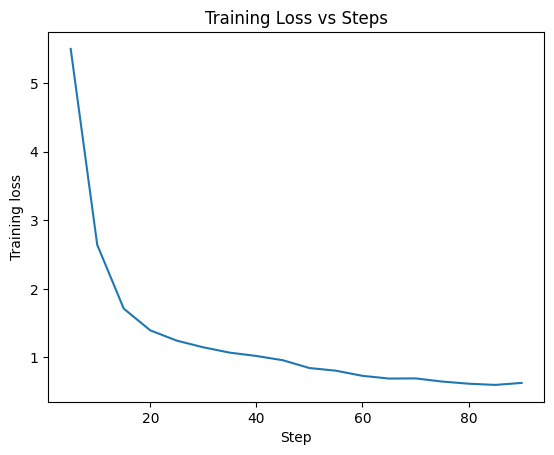

In [ ]:
# Q2: Plot Training Loss vs. Steps
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(trainer.state.log_history)

# keep rows that actually have loss + step
df_loss = df.dropna(subset=["loss", "step"])[["step", "loss"]].copy()

print("Loss points:", len(df_loss))
display(df_loss)

plt.figure()
# plt.plot(df_loss["step"], df_loss["train_loss"])
plt.plot(df_loss["step"], df_loss["loss"])
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("Training Loss vs Steps")
plt.show()

In [ ]:
# Q2: Generate examples before and after SFT
test_sentences = [
    "I love studying transformers.",
    "This coursework is difficult, but I am learning a lot.",
    "Please explain gradient descent in simple terms.",
]


def run(_model, sentence, prompt_template=USER_PROMPT_A2):
    msgs = [{"role": "user", "content": prompt_template.format(sentence=sentence)}]
    # print(msgs)  # debug use
    inputs = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(next(_model.parameters()).device)
    prompt_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = _model.generate(**inputs, max_new_tokens=128, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True).strip()


for s in test_sentences:
    print("Sentence:", s)
    print("Before SFT:", run(base, s))  # baseline chat model
    print("After  SFT:", run(model_sft, s))  # your trained translator
    print("\n")


Sentence: I love studying transformers.
Before SFT: Love I do, transformers studying.
After  SFT: Studying transformers, I love.

Sentence: This coursework is difficult, but I am learning a lot.
Before SFT: Difficult this coursework be, but much I learn, hmm.
After  SFT: Difficult, this coursework is, but a lot, I am learning.

Sentence: Please explain gradient descent in simple terms.
Before SFT: Explain, you must gradient descent, in simple terms, you do.
After  SFT: In simple terms, please explain gradient descent, you must.


### Q2 Answer:

**Training Loss Plot:**

![a2_loss_plot.png](a2_loss_plot.png)

**Examples Before and After SFT:**

Example 1:
- Input: I love studying transformers.
- Before SFT: Love I do, transformers studying.
- After SFT: Studying transformers, I love.

Example 2:
- Input: This coursework is difficult, but I am learning a lot.
- Before SFT: Difficult this coursework be, but much I learn, hmm.
- After SFT: Difficult, this coursework is, but a lot, I am learning.

Example 3:
- Input: Please explain gradient descent in simple terms.
- Before SFT: Explain, you must gradient descent, in simple terms, you do.
- After SFT: In simple terms, please explain gradient descent, you must.

## Q3: The Dataset Generation [8 marks]

**Task:** Generate a synthetic QA dataset with responses in "Yoda style".

**Deliverable:** Display 3 examples from your new synthetic dataset.

In [ ]:
# Q3: Load source dataset from HuggingFace
from datasets import load_dataset, DatasetDict

dolly = load_dataset("databricks/databricks-dolly-15k", split="train")

keep_cats = {"open_qa", "general_qa"}
dolly_qa = dolly.filter(lambda x: x["category"] in keep_cats)

# compute token length of the 'response' column using the tokenizer
dolly_qa = dolly_qa.map(
    lambda batch: {"resp_len": [len(tokenizer(r, truncation=False)["input_ids"]) for r in batch["response"]]},
    batched=True,
)

USER_PROMPT_A3 = "Rewrite the following sentence(s) in Yoda-style English. Output ONLY the rewritten sentence(s).\nSentence(s): {sentence}"

msgs = [{"role": "user", "content": USER_PROMPT_A3.format(sentence="")}]
# print(msgs)  # debug use
inputs = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(next(model_sft.parameters()).device)

prompt_len = inputs["input_ids"].shape[-1]
print(f"USER_PROMPT_A3 (with control tokens) prompt len: {prompt_len}")
# compute 25th and 75th percentiles and keep only responses within that range
p25, p75 = np.percentile(dolly_qa["resp_len"], [25, 75])
dolly_qa = dolly_qa.filter(lambda x: (x["resp_len"] >= int(p25)) and (x["resp_len"] <= 128 - prompt_len))  # as sft'ed using max_length=128

dolly_qa = dolly_qa.shuffle(seed=SEED)

USER_PROMPT_A3 (with control tokens) prompt len: 35


Filter:   0%|          | 0/5933 [00:00<?, ? examples/s]

In [ ]:
# Q3: Select random subsets (500 train, 200 validation, 500 test)
train_ds = dolly_qa.select(range(0, 500))
val_ds = dolly_qa.select(range(500, 700))
test_ds = dolly_qa.select(range(700, 1200))

raw_splits = DatasetDict(train=train_ds, validation=val_ds, test=test_ds)
# raw_splits

def to_qa(ex):
    q = ex["instruction"].strip()
    if ex.get("context") and ex["context"].strip():  # should not enter here as there should be no context in "open_qa" and "general_qa"
        q = q + "\n\nContext:\n" + ex["context"].strip()
    return {"question": q, "answer": ex["response"].strip(), "category": ex["category"]}

qa_splits = raw_splits.map(to_qa, remove_columns=raw_splits["train"].column_names)
qa_splits

DatasetDict({
    train: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 200
    })
    test: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 500
    })
})

In [ ]:
# Q3: Use trained translator to synthesize Yoda-style dataset
# safety: ensure model in eval mode and on the right device
model_sft.to(DEVICE)
model_sft.eval()


def yodafy_answer(batch):
    # batch["answer"] is a list of strings when map(..., batched=True)
    texts = batch["answer"] if isinstance(batch["answer"], list) else [batch["answer"]]

    # Build chat messages for each example using your prompt template
    msgs = [[{"role": "user", "content": USER_PROMPT_A3.format(sentence=t)}] for t in texts]

    # Tokenize/apply_chat_template for the whole batch at once
    inputs = tokenizer.apply_chat_template(
        msgs,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        padding=True,  # ensures each example in the batch is padded to the same length (the longest in the batch)
    ).to(next(model_sft.parameters()).device)

    # padded input prompt length, uniform across batch as padding=True
    # this tells us where the prompt ends in the returned generated sequences
    prompt_max_len = inputs["input_ids"].shape[1]  #
    # print("prompt_max_len:", prompt_max_len)  # debug use

    # single batched generation; inference_mode to save memory and speed up
    with torch.inference_mode():
        out_ids = model_sft.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            # num_beams=1, early_stopping=True, ... add your generation kwargs
        )

    # out_ids shape: (batch_size, seq_len_out)
    # decode only the generated portion for each sample
    generated = [
        tokenizer.decode(out_ids[i, prompt_max_len:], skip_special_tokens=True).strip() for i in range(out_ids.size(0))
    ]
    # print("generated:", generated)  # debug use

    # Return a list aligned with the incoming batch
    return {"answer_yoda": generated}

# start with a small batch size and increase if your GPU have enough VRAM, use 1 for CPU to avoid OOM
# past a certain point diminishing throughput returns —> the GPU compute becomes the bottleneck rather than memory
# 1 (without batching) costs ~35mins, 32 costs >6mins, 128 ~4mins (~5.6/s), 256 ~3.5mins (~6.4/s) on DGX Spark
BATCH_SIZE = 256 if torch.cuda.is_available() else 1  # TODO
qa_splits_yoda = qa_splits.map(yodafy_answer, batched=True, batch_size=BATCH_SIZE)
qa_splits_yoda

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['category', 'question', 'answer', 'answer_yoda'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['category', 'question', 'answer', 'answer_yoda'],
        num_rows: 200
    })
    test: Dataset({
        features: ['category', 'question', 'answer', 'answer_yoda'],
        num_rows: 500
    })
})

In [ ]:
# [optional] save dataset on disk
import datetime
from pathlib import Path
from datasets import load_from_disk

try:
    RUN_ID  # exists?
except NameError:
    models_dir = Path("models")
    pattern = f"{MODEL_NAME}-a2-*"
    candidates = sorted(models_dir.glob(pattern))
    if candidates:
        latest = max(candidates, key=lambda p: p.stat().st_mtime)
        RUN_ID = latest.name.rsplit("-", 1)[-1]
    else:
        from datetime import datetime

        RUN_ID = datetime.now().strftime("%m%d%H%M%S")
print(f"RUN_ID: {RUN_ID}")

SAVE_DIR = Path("datasets") / f"dolly_qa_yoda_{RUN_ID}_{datetime.datetime.now().strftime('%H%M%S')}"
SAVE_DIR.parent.mkdir(parents=True, exist_ok=True)

qa_splits_yoda.save_to_disk(str(SAVE_DIR))
print("Saved to:", SAVE_DIR)

RUN_ID: 0227075933


Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saved to: datasets/dolly_qa_yoda_0227075933_205525


In [ ]:
# [optional] load dataset from disk
from datasets import load_from_disk

try:
    SAVE_DIR
except NameError:
    SAVE_DIR = Path("datasets") / f"dolly_qa_yoda_0227075933_205525"

qa_splits_yoda = load_from_disk(str(SAVE_DIR))  # your path
# qa_splits_yoda

# Sample and display 3 examples from qa_splits_yoda (train split)
import random

random.seed(SEED)  # pick any to see more examples

split = "train" if "train" in qa_splits_yoda else list(qa_splits_yoda.keys())[0]
n = len(qa_splits_yoda[split])
if n == 0:
    print("No examples in dataset split:", split)
else:
    indices = random.sample(range(n), min(3, n))
    for idx_num, idx in enumerate(indices, 1):
        ex = qa_splits_yoda[split][idx]
        print(f"Example {idx_num} (split={split}, index={idx}):")
        print("Question:", ex.get("question", ""))
        print("Original Answer:", ex.get("answer", ""))
        print("Yoda-style Answer:", ex.get("answer_yoda", ""))
        print("-" * 80)

Example 1 (split=train, index=327):
Question: What are some examples of popular sitcoms on television in the 1980s?
Original Answer: Popular sitcoms that were on television in the 1980s include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
Yoda-style Answer: That were on television in the 1980s, popular sitcoms, include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
--------------------------------------------------------------------------------
Example 2 (split=train, index=57):
Question: What's the difference between a wolf and a dog?
Original Answer: A dog is a domesticated pet, while a wolf is a wild animal. They both are part of the same species, and share a lot of physical similarities, but at the same time display very different behaviour.
Yoda-style Answer: A domesticated pet, a dog is, while a wild animal, a wolf is. Both, part of the same species, share a lot of physical similarities, but very different behaviou

### Q3 Answer:

**Source Dataset:**
We picked a filtered [databricks/databricks-dolly-15k](https://huggingface.co/datasets/databricks/databricks-dolly-15k) with category `open_qa` and `general_qa` only. It is a well-structured, high quality and instruction-following dataset, which is designed specifically for instruction fine-tuning SLMs. We filtered the dataset to keep only the examples from these two categories because they contain questions answerable from general knowledge alone, without needing a provided context passage. Other categories like `closed_qa`, `summarization`, or `classification` require a context chunk, which complicates the prompt format and conflicts with the Yoda-style SFT task (which targets simple Q&A pairs). We further limit those with response token length between 25th percentiles and `128-35 (prompt token length) = 93` to avoid extremely short and out of max_length response. We then selected random subsets of 500 for training, 200 for validation, and 500 for testing.

**Examples from Synthetic Dataset:**

Example 1:
- Question: What are some examples of popular sitcoms on television in the 1980s?
- Original Answer: Popular sitcoms that were on television in the 1980s include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
- Yoda-style Answer: That were on television in the 1980s, popular sitcoms, include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.

Example 2:
- Question: What's the difference between a wolf and a dog?
- Original Answer: A dog is a domesticated pet, while a wolf is a wild animal. They both are part of the same species, and share a lot of physical similarities, but at the same time display very different behaviour.
- Yoda-style Answer: A domesticated pet, a dog is, while a wild animal, a wolf is. Both, part of the same species, share a lot of physical similarities, but very different behaviour, they do.

Example 3:
- Question: Which months were added to the calendar and why?
- Original Answer: In order for the Roman calendar year which was ten months long, to be in sync with the lunar year, the months of January and February were added.
- Yoda-style Answer: In sync with the lunar year, the Roman calendar year, ten months long, to be, must. The months of January and February, added, were.


## Q4: SFT to Respond like Yoda [15 marks]

**Task:** Train the final model to respond like Yoda using the validation dataset to monitor training.

**Deliverables:**
- Provide a plot of the Training Loss vs. Steps and three examples of the responses before and after SFT. Also, report the validation loss.
- (100 words) Discuss the training procedure.
- (100 words) Assess the generalization of the models.

In [ ]:
# Q4: Train the model to respond like Yoda
USER_PROMPT_A4 = "Answer the question in Yoda-style English. Output ONLY the answer.\nQuestion: {sentence}"


def create_prompt_a4(ex):
    return {
        "messages": [
            {"role": "user", "content": USER_PROMPT_A4.format(sentence=ex["question"])},
            {"role": "assistant", "content": ex["answer_yoda"]},
        ]
    }


# remove og columns to save disk space and avoid confusion, only keep the "messages" column which is used for training
train_a4 = qa_splits_yoda["train"].map(create_prompt_a4, remove_columns=qa_splits_yoda["train"].column_names)
val_a4 = qa_splits_yoda["validation"].map(create_prompt_a4, remove_columns=qa_splits_yoda["validation"].column_names)
test_a4 = qa_splits_yoda["test"].map(create_prompt_a4)  # keep original question/answer columns for final evaluation

train_a4, val_a4, test_a4

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

(Dataset({
     features: ['messages'],
     num_rows: 500
 }),
 Dataset({
     features: ['messages'],
     num_rows: 200
 }),
 Dataset({
     features: ['category', 'question', 'answer', 'answer_yoda', 'messages'],
     num_rows: 500
 }))

In [ ]:
import math

# recompute warmup_steps based on the new train_a4 dataset size
epochs = 6
n_train = len(train_a4)  # 500
steps_per_epoch = math.ceil(n_train / per_device_train_batch_size / gradient_accumulation_steps)
total_steps = steps_per_epoch * epochs
warmup_steps = max(1, math.ceil(0.03 * total_steps))

print("steps_per_epoch:", steps_per_epoch)
print("total_steps:", total_steps)
print("warmup_steps:", warmup_steps)

sft_config_a4 = dict(sft_config)  # copy a2 config
sft_config_a4.update({
    "output_dir": RUN_DIR % 4,  # a4 folder

    "hub_model_id": f"chubao/{MODEL_NAME}-a4",  # suffixed in a4

    "max_length": 256,  # QA answers can be longer than single sentence
    "num_train_epochs": epochs,  # number of training epochs
    "warmup_steps": warmup_steps,
    # validation monitoring
    "eval_strategy": "steps",
    "eval_steps": 10,
    # checkpointing (keep aligned with eval)
    "save_strategy": "steps",
    "save_steps": 10,
    # best checkpoint selection
    "load_best_model_at_end": True,  # coz we have eval set
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,  # lowest eval_loss is best
    "per_device_eval_batch_size": per_device_train_batch_size,
    "save_total_limit": 2,  # no need to save many ckpts, only the best and the latest
})
args_a4 = SFTConfig(**sft_config_a4)

steps_per_epoch: 16
total_steps: 96
warmup_steps: 3


In [ ]:
from peft import get_peft_model
from trl import SFTTrainer

# fresh model for A4
if 'model_a4' in globals():
    del model_a4
# feel free to in case you have limited memory on your GPU
# clear_memory()
model_a4 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model_a4 = get_peft_model(model_a4, lora_config)

trainer_a4 = SFTTrainer(
    model=model_a4,
    args=args_a4,
    train_dataset=train_a4,
    eval_dataset=val_a4,
    processing_class=tokenizer,
)

trainer_a4.train()
trainer_a4.save_model()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss,Validation Loss
10,2.827824,2.256565
20,2.028976,1.922867
30,1.763805,1.780874
40,1.720710,1.687371
50,1.588905,1.602394
60,1.498877,1.543784
70,1.356627,1.523619
80,1.304488,1.531381
90,1.082268,1.653236


In [ ]:
# [optional] push a4 model to huggingface hub
trainer_a4.push_to_hub()
print("hub_model_id:", getattr(trainer_a4.args, "hub_model_id", None))
print("push_to_hub:", trainer_a4.args.push_to_hub)
print("hub_strategy:", getattr(trainer_a4.args, "hub_strategy", None))

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

ReadTimeout: The read operation timed out

In [ ]:
# [optional] load latest run local a4 model to avoid retraining
tokenizer_a4, model_a4, LATEST_RUN_DIR_A4, LATEST_CKPT_DIR_A4 = load_sft_adapter()

# quick sanity check
print("model_sft device:", next(model_a4.parameters()).device)

In [ ]:
# [optional] load model_a4 directly from hugging face
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("chubao/gemma2-2b-yoda-a4")
# Step 1: load base model
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)

# Step 2: overlay the adapter from hub
model_a4 = PeftModel.from_pretrained(base, "chubao/gemma2-2b-yoda-a4").eval()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [ ]:
import pandas as pd

df = pd.DataFrame(trainer_a4.state.log_history)

df_eval = df.dropna(subset=["eval_loss", "step"])[["step", "eval_loss"]]
display(df_eval.tail())

final_val_loss = df_eval.iloc[-1]["eval_loss"]
best_val_loss = df_eval["eval_loss"].min()

print("Final validation loss:", float(final_val_loss))
print("Best  validation loss:", float(best_val_loss))

,step,eval_loss
14,50,1.602394
17,60,1.543784
20,70,1.523619
23,80,1.531381
26,90,1.653236


Final validation loss: 1.6532362699508667
Best  validation loss: 1.5236190557479858


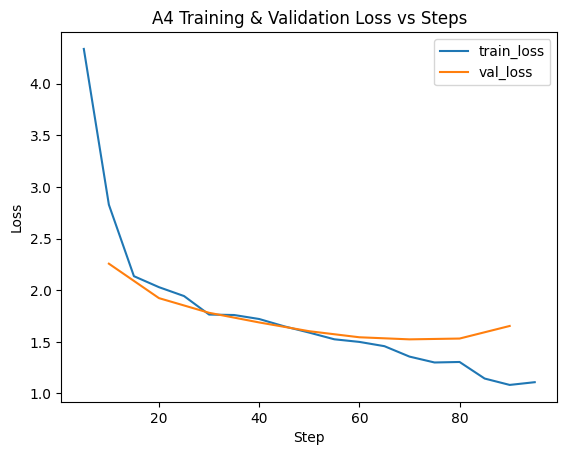

In [ ]:
# Q4: Plot Training Loss vs. Steps
import matplotlib.pyplot as plt

df_train = df.dropna(subset=["loss", "step"])[["step", "loss"]]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="train_loss")
plt.plot(df_eval["step"], df_eval["eval_loss"], label="val_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("A4 Training & Validation Loss vs Steps")
plt.legend()
plt.show()

In [ ]:
# Q4: Generate examples before and after SFT
import random

# Reuse A2 `run()` helper: it formats using `{sentence}`.

# Ensure models are in eval mode for generation
model_sft.eval()
model_a4.eval()

random.seed(SEED)
sample_ids = random.sample(range(len(qa_splits_yoda["test"])), 3)

for i, idx in enumerate(sample_ids, 1):
    ex = qa_splits_yoda["test"][idx]
    q = ex["question"]
    print(f"Example {i} (test idx={idx})")
    print("- Question:", q)
    print("- Before SFT:", run(model_sft, q, prompt_template=USER_PROMPT_A4))
    print("- After  SFT:", run(model_a4, q, prompt_template=USER_PROMPT_A4))
    print()

Example 1 (test idx=327)
- Question: What sport is Ruud Gullit known for
- Before SFT: Known for soccer, he is.
- After  SFT: A Dutch football player, Ruud Gullit is. In the 1980s and 1990s, he played for Ajax, AC Milan, and Chelsea. A famous Dutch football player, he is, and one of the best Dutch footballers of all time, considered.

Example 2 (test idx=57)
- Question: Who first described the Euphalacra lacunata
- Before SFT: First described the Euphalacra lacunata, who did?
- After  SFT: In 1863, the species Euphalacra lacunata, the first described, was. By the German naturalist, Johann Friedrich Wilhelm von Müller, it was.

Example 3 (test idx=12)
- Question: What do players of American football wear helmets? Write the response as if your are an American explaining to a coworker from another country.
- Before SFT: To protect their heads, players wear helmets.
- After  SFT: To protect their head and face, players of American football wear helmets. Yes, hrrmmm. The helmets are made of

### Q4 Answer:

**Training and Validation Loss Plot:**

![a4_loss_plot.png](a4_loss_plot.png)

**Examples Before and After SFT:**

Example 1 (test idx=327)
- Question: What sport is Ruud Gullit known for
- Before SFT: Known for soccer, he is.
- After  SFT: A Dutch football player, Ruud Gullit is. In the 1980s and 1990s, he played for Ajax, AC Milan, and Chelsea. A famous Dutch football player, he is, and one of the best Dutch footballers of all time, considered.

Example 2 (test idx=57)
- Question: Who first described the Euphalacra lacunata
- Before SFT: First described the Euphalacra lacunata, who did?
- After  SFT: In 1863, the species Euphalacra lacunata, the first described, was. By the German naturalist, Johann Friedrich Wilhelm von Müller, it was.

Example 3 (test idx=12)
- Question: What do players of American football wear helmets? Write the response as if your are an American explaining to a coworker from another country.
- Before SFT: To protect their heads, players wear helmets.
- After  SFT: To protect their head and face, players of American football wear helmets. Yes, hrrmmm. The helmets are made of a hard plastic material, and have a padding inside to absorb the impact of a hit.

**Discussion of Training Procedure (100 words):**

For A4, I fine-tuned A2's [chubao/gemma2-2b-yoda](https://huggingface.co/chubao/gemma2-2b-yoda) with LoRA using TRL’s SFTTrainer on a synthetic QA dataset created in Q3. The user prompt is "Answer the question in Yoda-style English" and the assistant's target was the synthesized answer in Yoda's style. I trained for 6 epochs with a per_device_train_batch_size of 8 and 4 gradient accumulation steps, resulting in an effective batch size of 32. This setup led to 16 steps per epoch, totaling 96 steps. The U-shaped validation loss curve shows textbook overfitting. I saved 2 checkpoints with only the best checkpoint (step 70) based on eval_loss (token-level cross-entropy) and the last one.

**Assessment of Generalization (100 words):**

Generalization was examined using three random test questions. Outputs from before were compared to outputs after SFT, all using the same Yoda-style prompt. After SFT, the model showed an improvement. It answered questions directly and provided richer content. In example 1, it identified Ruud Gullit as a Dutch football player and included details about his career while maintaining the Yoda-like word order and fillers. The model learned not just the style but also the mapping between Q&A, rather than simply rewriting. Since the targets are synthetic, factual accuracy is not guaranteed, which means some hallucinations may still occur.


---

# Part B: Reinforcement Learning from Verifiable Rewards (RLVR) [60 marks]

**Objective:** Apply RLVR to train a model that performs reasoning tasks while maintaining Yoda-style responses.

## Q1: Reward Model Training [10 marks]

**Task:** Train a binary classifier to identify Yoda-style text.

**Deliverable:** Provide a plot of the Training Loss vs. Steps and the accuracy of the classifier on a held-out test set.

In [ ]:
# Q1: Create balanced dataset of Yoda-style and standard English
# TODO: Add your code here
# Q1 - Cell 47: Create a balanced reward-model dataset
import gc
import re
from pathlib import Path

import torch
from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# cleanup
for name in ["base", "model_sft", "model_a4", "translator_model", "model_clf"]:
    if name in globals():
        try:
            del globals()[name]
        except Exception:
            pass
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# settings
REWARD_SOURCE_SIZE = 180
TRANSLATE_BATCH_SIZE = 1
MAX_TRANSLATE_NEW_TOKENS = 96


def clean_style_text(text: str) -> str:
    text = str(text)
    text = text.replace("\u00a0", " ")
    text = re.sub(r"<<.*?>>", " ", text)
    text = re.sub(r"\s*####\s*[-+]?\d[\d,]*(?:\.\d+)?\s*$", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def load_latest_a2_translator_light(models_root="models"):
    models_root = Path(models_root)
    run_dirs = sorted(models_root.glob(f"{MODEL_NAME}-a2-*"))
    if not run_dirs:
        raise FileNotFoundError("No local A2 translator run found.")

    latest_run = max(run_dirs, key=lambda p: p.stat().st_mtime)

    ckpts = []
    for p in latest_run.iterdir():
        if p.is_dir():
            m = re.match(r"checkpoint-(\d+)$", p.name)
            if m:
                ckpts.append((int(m.group(1)), p))
    ckpt_dir = max(ckpts, key=lambda x: x[0])[1] if ckpts else latest_run

    print("Latest A2 run dir:", latest_run)
    print("Using A2 checkpoint:", ckpt_dir)

    tok_source = str(latest_run) if (latest_run / "tokenizer_config.json").exists() else MODEL_ID
    translator_tokenizer = AutoTokenizer.from_pretrained(tok_source)
    if translator_tokenizer.pad_token is None:
        translator_tokenizer.pad_token = translator_tokenizer.eos_token

    # important: avoid duplicated device_map in model_kwargs
    load_kwargs = dict(model_kwargs)
    load_kwargs.pop("device_map", None)

    translator_base = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        device_map=DEVICE_MAP,
        low_cpu_mem_usage=True,
        **load_kwargs
    )

    translator_model = PeftModel.from_pretrained(translator_base, str(ckpt_dir)).eval()
    return translator_tokenizer, translator_model


translator_tokenizer, translator_model = load_latest_a2_translator_light()

reward_source = (
    load_dataset("gsm8k", "main", split="train")
    .shuffle(seed=SEED)
    .select(range(REWARD_SOURCE_SIZE))
)

tmp = reward_source.train_test_split(test_size=0.2, seed=SEED)
train_val = tmp["train"].train_test_split(test_size=0.125, seed=SEED)

reward_source_splits = DatasetDict({
    "train": train_val["train"],
    "validation": train_val["test"],
    "test": tmp["test"],
})

print("Raw source split sizes:", {k: len(v) for k, v in reward_source_splits.items()})


def translate_one_by_one(ds, split_name):
    standard_texts = []
    yoda_texts = []

    old_padding_side = translator_tokenizer.padding_side
    translator_tokenizer.padding_side = "left"

    device = next(translator_model.parameters()).device

    for i, ex in enumerate(ds):
        source_text = clean_style_text(ex["answer"])

        prompt = translator_tokenizer.apply_chat_template(
            [{"role": "user", "content": USER_PROMPT_A2.format(sentence=source_text)}],
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = translator_tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
        ).to(device)

        with torch.inference_mode():
            out = translator_model.generate(
                **inputs,
                max_new_tokens=MAX_TRANSLATE_NEW_TOKENS,
                do_sample=False,
                use_cache=False,
                pad_token_id=translator_tokenizer.eos_token_id,
                eos_token_id=translator_tokenizer.eos_token_id,
            )

        gen_tokens = out[:, inputs["input_ids"].shape[1]:]
        yoda = translator_tokenizer.decode(gen_tokens[0], skip_special_tokens=True).strip()
        yoda = re.sub(r"\s+", " ", yoda)

        standard_texts.append(source_text)
        yoda_texts.append(yoda)

        if (i + 1) % 20 == 0:
            print(f"{split_name}: translated {i+1}/{len(ds)}")
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    translator_tokenizer.padding_side = old_padding_side

    positives = Dataset.from_dict({
        "text": yoda_texts,
        "label": [1] * len(yoda_texts),
    })
    negatives = Dataset.from_dict({
        "text": standard_texts,
        "label": [0] * len(standard_texts),
    })

    merged = concatenate_datasets([positives, negatives])
    merged = merged.filter(lambda ex: len(str(ex["text"]).strip()) > 0)
    return merged.shuffle(seed=SEED)


classifier_splits = {}
for split in ["train", "validation", "test"]:
    classifier_splits[split] = translate_one_by_one(reward_source_splits[split], split)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

classifier_dataset = DatasetDict(classifier_splits)

print("Classifier split sizes:", {k: len(v) for k, v in classifier_dataset.items()})
print(classifier_dataset["train"][0])

del translator_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Using A2 checkpoint from Hugging Face: chubao/gemma2-2b-yoda


tokenizer_config.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/591 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/83.1M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Raw source split sizes: {'train': 126, 'validation': 18, 'test': 36}
train: translated 20/126
train: translated 40/126


KeyboardInterrupt: 

In [ ]:
classifier_dataset.save_to_disk("./classifier_dataset")
print("classifier_dataset saved.")

In [ ]:
# Q1: Train binary classifier
# TODO: Add your code here
# Q1 - Cell 2: Train the style classifier

import gc
import numpy as np
import torch

from datasets import load_from_disk
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# Load dataset if needed
if "classifier_dataset" not in globals():
    classifier_dataset = load_from_disk("./classifier_dataset")
    print("Loaded classifier_dataset from disk.")

print("Classifier split sizes:", {k: len(v) for k, v in classifier_dataset.items()})

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load tokenizer + model
clf_model_name = "distilbert-base-uncased"

tokenizer_clf = AutoTokenizer.from_pretrained(clf_model_name, use_fast=True)
model_clf = AutoModelForSequenceClassification.from_pretrained(
    clf_model_name,
    num_labels=2,
)

# Tokenize
def tokenize_clf(batch):
    return tokenizer_clf(
        batch["text"],
        truncation=True,
        max_length=256,
    )

tokenized_clf_ds = classifier_dataset.map(
    tokenize_clf,
    batched=True,
    desc="Tokenizing classifier dataset"
)

if "label" in tokenized_clf_ds["train"].column_names:
    tokenized_clf_ds = tokenized_clf_ds.rename_column("label", "labels")

if "text" in tokenized_clf_ds["train"].column_names:
    tokenized_clf_ds = tokenized_clf_ds.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_clf)

# accuracy metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = float((preds == labels).mean())
    return {"accuracy": acc}

#  Training args
common_training_kwargs = dict(
    output_dir="./yoda_style_classifier_ckpts",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=10,
    report_to="none",
    seed=SEED if "SEED" in globals() else 42,
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=False,
)

try:
    training_args_clf = TrainingArguments(
        eval_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args_clf = TrainingArguments(
        evaluation_strategy="epoch",
        **common_training_kwargs,
    )

#  Trainer
trainer_clf = Trainer(
    model=model_clf,
    args=training_args_clf,
    train_dataset=tokenized_clf_ds["train"],
    eval_dataset=tokenized_clf_ds["validation"],
    processing_class=tokenizer_clf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train
train_result_clf = trainer_clf.train()
model_clf = trainer_clf.model.eval()

print(train_result_clf)

In [ ]:
# Q1: Plot Training Loss vs. Steps
# TODO: Add your code here
# Q1 - Cell 3: Plot training loss

import pandas as pd
import matplotlib.pyplot as plt

if "trainer_clf" not in globals():
    raise RuntimeError("trainer_clf is not defined. Run Q1 - Cell 2 first.")

history = pd.DataFrame(trainer_clf.state.log_history)

train_logs = history.dropna(subset=["loss", "step"])[["step", "loss"]].copy()

print(train_logs.head())
print(f"Number of logged training points: {len(train_logs)}")

plt.figure(figsize=(8, 5))
plt.plot(train_logs["step"], train_logs["loss"])
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Q1 Reward Model Training Loss vs Steps")
plt.grid(True)
plt.show()


In [ ]:
# Q1: Evaluate classifier on test set
# TODO: Add your code here
# Q1 -Evaluate on held-out test set and save classifier
import os
import gc
import numpy as np
import torch
from torch.utils.data import DataLoader

if "model_clf" not in globals():
    raise RuntimeError("model_clf is not defined. Run Q1 - Cell 2 first.")

if "tokenized_clf_ds" not in globals():
    raise RuntimeError("tokenized_clf_ds is not defined. Run Q1 - Cell 2 first.")

if "tokenizer_clf" not in globals():
    raise RuntimeError("tokenizer_clf is not defined. Run Q1 - Cell 2 first.")

device = next(model_clf.parameters()).device
model_clf.eval()

# Build dataloader for held-out test split
test_dataset = tokenized_clf_ds["test"]
test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=data_collator,
)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()

        batch = {
            k: v.to(device) if hasattr(v, "to") else v
            for k, v in batch.items()
        }

        outputs = model_clf(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],
        )

        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = float((all_preds == all_labels).mean())

print(f"Held-out test accuracy: {test_accuracy:.4f}")
print(f"Num test examples: {len(all_labels)}")

# Save classifier
STYLE_CKPT_DIR = "./yoda_style_classifier"
os.makedirs(STYLE_CKPT_DIR, exist_ok=True)

# Save model weights
model_clf.save_pretrained(STYLE_CKPT_DIR)
tokenizer_clf.save_pretrained(STYLE_CKPT_DIR)

print(f"Saved style classifier to: {STYLE_CKPT_DIR}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()



## Q2: Reward Function Design [10 marks]

**Task:** Design and implement a reward function that is a linear combination of three components: correctness, format, and style.

**Deliverable:** Show reward scores (all three components plus total) for 3 diverse responses. Explain why each component is necessary and whether the obtained rewards match your expectations.

In [ ]:
# Q2: Implement correctness reward
# TODO: Add your code here
# Setup helpers and load style classifier

import re
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Expected output format for RL in later questions
REQUIRED_RESPONSE_FORMAT = """<reasoning>
...
</reasoning>
<answer>
...
</answer>"""

REASONING_RE = re.compile(
    r"<reasoning>\s*(.*?)\s*</reasoning>",
    flags=re.IGNORECASE | re.DOTALL
)
ANSWER_RE = re.compile(
    r"<answer>\s*(.*?)\s*</answer>",
    flags=re.IGNORECASE | re.DOTALL
)
NUMBER_RE = re.compile(r"[-+]?\d[\d,]*(?:\.\d+)?")


# Load style classifier from Q1
STYLE_CKPT_DIR = "./yoda_style_classifier"

tokenizer_clf = AutoTokenizer.from_pretrained(STYLE_CKPT_DIR)
model_clf = AutoModelForSequenceClassification.from_pretrained(STYLE_CKPT_DIR)

STYLE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_clf = model_clf.to(STYLE_DEVICE).eval()

print("Loaded style classifier from:", STYLE_CKPT_DIR)
print("Style device:", STYLE_DEVICE)
print("Expected response format:")
print(REQUIRED_RESPONSE_FORMAT)

# Generic completion -> text helper
# Works for strings, dicts, or chat-format lists
def completion_to_text(completion):
    if isinstance(completion, str):
        return completion.strip()

    if isinstance(completion, dict):
        if "content" in completion:
            return str(completion["content"]).strip()
        return str(completion).strip()

    if isinstance(completion, list):
        parts = []
        for item in completion:
            if isinstance(item, dict) and "content" in item:
                parts.append(str(item["content"]))
            else:
                parts.append(str(item))
        return "\n".join(parts).strip()

    return str(completion).strip()


def normalize_answer_text(text: str) -> str:
    text = str(text).strip()
    text = text.replace(",", "")
    text = re.sub(r"^\$+", "", text)
    text = re.sub(r"\s+", " ", text)

    # normalize numeric strings
    if re.fullmatch(r"[-+]?\d+(?:\.\d+)?", text):
        value = float(text)
        if value.is_integer():
            return str(int(value))
        return str(value).rstrip("0").rstrip(".")

    return text.lower()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded style classifier from: ./yoda_style_classifier
Style device: cuda
Expected response format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>


In [ ]:
# Q2: Implement format reward
# TODO: Add your code here
# Q2 Correctness reward for GSM8K

def extract_gold_gsm8k_answer(gold_answer: str) -> str:
    gold_answer = str(gold_answer)

    # GSM8K usually ends with #### final_answer
    if "####" in gold_answer:
        candidate = gold_answer.split("####")[-1].strip()
        return normalize_answer_text(candidate)

    nums = NUMBER_RE.findall(gold_answer)
    return normalize_answer_text(nums[-1] if nums else gold_answer.strip())


def extract_predicted_answer(response) -> str:
    text = completion_to_text(response)

    # Prefer <answer>...</answer>
    m = ANSWER_RE.search(text)
    if m:
        answer_text = m.group(1).strip()
    else:
        answer_text = text.strip()

    # remove optional prefixes
    answer_text = re.sub(
        r"^(final answer|answer)\s*:\s*",
        "",
        answer_text,
        flags=re.IGNORECASE
    ).strip()

    nums = NUMBER_RE.findall(answer_text)
    if nums:
        return normalize_answer_text(nums[-1])

    lines = [x.strip() for x in answer_text.splitlines() if x.strip()]
    if lines:
        return normalize_answer_text(lines[-1])

    return ""


def correctness_reward_single(response, gold_answer: str) -> float:
    pred = extract_predicted_answer(response)
    gold = extract_gold_gsm8k_answer(gold_answer)
    return float(pred == gold)


def correctness_reward_batch(completions, gold_answer=None, answers=None, solution=None, **kwargs):
    refs = gold_answer if gold_answer is not None else answers
    refs = refs if refs is not None else solution
    if refs is None:
        raise ValueError("Need one of: gold_answer, answers, or solution")
    return [correctness_reward_single(c, a) for c, a in zip(completions, refs)]

In [ ]:
# Q2: Implement style reward (using classifier from Q1)
# TODO: Add your code here
# Q2 Format reward + style reward

def format_reward_single(response) -> float:
    """
    Dense rule-based reward in [0, 1].
    Expected format:
    <reasoning> ... </reasoning>
    <answer> ... </answer>
    """
    text = completion_to_text(response).strip()

    m_reasoning = REASONING_RE.search(text)
    m_answer = ANSWER_RE.search(text)

    reasoning_text = m_reasoning.group(1).strip() if m_reasoning else ""
    answer_text = m_answer.group(1).strip() if m_answer else ""

    score = 0.0

    # non-empty reasoning block
    if reasoning_text:
        score += 0.4

    # non-empty answer block
    if answer_text:
        score += 0.4

    # correct order: reasoning before answer
    if m_reasoning and m_answer and m_reasoning.start() < m_answer.start():
        score += 0.1

    # no extra text outside the two tags
    remainder = REASONING_RE.sub("", text)
    remainder = ANSWER_RE.sub("", remainder)
    if remainder.strip() == "":
        score += 0.1

    return float(min(score, 1.0))


def format_reward_batch(completions, **kwargs):
    return [format_reward_single(c) for c in completions]


def strip_format_tags(text: str) -> str:
    """
    Remove the XML-like tags but keep their contents,
    so the classifier scores style rather than markup.
    """
    text = REASONING_RE.sub(lambda m: " " + m.group(1).strip() + " ", text)
    text = ANSWER_RE.sub(lambda m: " " + m.group(1).strip() + " ", text)
    text = re.sub(r"</?(reasoning|answer)>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def style_reward_single(response) -> float:
    text = strip_format_tags(completion_to_text(response))
    if not text:
        return 0.0

    inputs = tokenizer_clf(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
    ).to(STYLE_DEVICE)

    with torch.no_grad():
        logits = model_clf(**inputs).logits
        prob_yoda = torch.softmax(logits, dim=-1)[0, 1].item()

    return float(prob_yoda)


def style_reward_batch(completions, **kwargs):
    return [style_reward_single(c) for c in completions]

In [ ]:
# Q2: Implement composite reward function
# TODO: Add your code here
#  Composite reward

# correctness is the main objective
REWARD_WEIGHTS = {
    "correctness": 1.0,
    "format": 0.25,
    "style": 0.25,
}

# useful for Q3 later (correctness + format only)
REWARD_WEIGHTS_CF_ONLY = {
    "correctness": 1.0,
    "format": 0.25,
}


def total_reward_single(response, gold_answer: str, weights=REWARD_WEIGHTS):
    c = correctness_reward_single(response, gold_answer)
    f = format_reward_single(response)
    s = style_reward_single(response)

    total = (
        weights["correctness"] * c
        + weights["format"] * f
        + weights["style"] * s
    )

    return {
        "correctness": c,
        "format": f,
        "style": s,
        "total": float(total),
    }


def total_reward_cf_only_single(response, gold_answer: str, weights=REWARD_WEIGHTS_CF_ONLY):
    c = correctness_reward_single(response, gold_answer)
    f = format_reward_single(response)

    total = (
        weights["correctness"] * c
        + weights["format"] * f
    )

    return {
        "correctness": c,
        "format": f,
        "total": float(total),
    }


def total_reward_batch(completions, gold_answer=None, answers=None, solution=None, **kwargs):
    refs = gold_answer if gold_answer is not None else answers
    refs = refs if refs is not None else solution
    if refs is None:
        raise ValueError("Need one of: gold_answer, answers, or solution")
    return [total_reward_single(c, a)["total"] for c, a in zip(completions, refs)]


def total_reward_cf_only_batch(completions, gold_answer=None, answers=None, solution=None, **kwargs):
    refs = gold_answer if gold_answer is not None else answers
    refs = refs if refs is not None else solution
    if refs is None:
        raise ValueError("Need one of: gold_answer, answers, or solution")
    return [total_reward_cf_only_single(c, a)["total"] for c, a in zip(completions, refs)]


print("Full reward weights:", REWARD_WEIGHTS)
print("CF-only reward weights:", REWARD_WEIGHTS_CF_ONLY)

Full reward weights: {'correctness': 1.0, 'format': 0.25, 'style': 0.25}
CF-only reward weights: {'correctness': 1.0, 'format': 0.25}


In [ ]:
# Q2: Demonstrate reward scores on 3 diverse examples
# TODO: Add your code here
# Show reward scores for 3 diverse responses

def make_wrong_answer(correct_answer: str) -> str:
    try:
        if "." in correct_answer:
            value = float(correct_answer)
            return str(value + 1.0).rstrip("0").rstrip(".")
        value = int(correct_answer)
        return str(value + 1)
    except Exception:
        return "999999"

# load one example from GSM8K test split
gsm8k_test = load_dataset("gsm8k", "main", split="test")
demo_example = gsm8k_test[0]

demo_question = demo_example["question"]
demo_gold_answer = demo_example["answer"]
demo_gold_final = extract_gold_gsm8k_answer(demo_gold_answer)
demo_wrong_final = make_wrong_answer(demo_gold_final)

demo_responses = [
    {
        "case": "Correct + correct format + Yoda-like",
        "response": f"""<reasoning>
Carefully, the quantities I combine. The final value, {demo_gold_final}, it is.
</reasoning>
<answer>
{demo_gold_final}
</answer>"""
    },
    {
        "case": "Correct answer but bad format / plain style",
        "response": f"The answer is {demo_gold_final}."
    },
    {
        "case": "Good format + Yoda-like, but wrong answer",
        "response": f"""<reasoning>
Compute it, I try. A mistake in arithmetic, however, I made. The result, {demo_wrong_final}, I claim.
</reasoning>
<answer>
{demo_wrong_final}
</answer>"""
    },
]

rows = []
for item in demo_responses:
    scores = total_reward_single(item["response"], demo_gold_answer)
    rows.append({
        "case": item["case"],
        "response": item["response"],
        "correctness": scores["correctness"],
        "format": scores["format"],
        "style": round(scores["style"], 4),
        "total": round(scores["total"], 4),
    })

reward_demo_df = pd.DataFrame(rows)

print("Demo question:")
print(demo_question)
print("\nGold final answer:", demo_gold_final)
print("\nExpected response format:")
print(REQUIRED_RESPONSE_FORMAT)

display(reward_demo_df[["case", "correctness", "format", "style", "total"]])

for _, row in reward_demo_df.iterrows():
    print("=" * 100)
    print("Case:", row["case"])
    print(row["response"])
    print(
        f"\ncorrectness={row['correctness']}, "
        f"format={row['format']}, "
        f"style={row['style']}, "
        f"total={row['total']}"
    )

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Demo question:
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Gold final answer: 18

Expected response format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>


,case,correctness,format,style,total
0,Correct + correct format + Yoda-like,1.0,1.0,0.8985,1.4746
1,Correct answer but bad format / plain style,1.0,0.0,0.1951,1.0488
2,"Good format + Yoda-like, but wrong answer",0.0,1.0,0.9145,0.4786


Case: Correct + correct format + Yoda-like
<reasoning>
Carefully, the quantities I combine. The final value, 18, it is.
</reasoning>
<answer>
18
</answer>

correctness=1.0, format=1.0, style=0.8985, total=1.4746
Case: Correct answer but bad format / plain style
The answer is 18.

correctness=1.0, format=0.0, style=0.1951, total=1.0488
Case: Good format + Yoda-like, but wrong answer
<reasoning>
Compute it, I try. A mistake in arithmetic, however, I made. The result, 19, I claim.
</reasoning>
<answer>
19
</answer>

correctness=0.0, format=1.0, style=0.9145, total=0.4786


### Q2 Answer:

**Reward Scores for 3 Diverse Responses:**

Example 1:
- Response: [Your response]
- Correctness Reward: [Score]
- Format Reward: [Score]
- Style Reward: [Score]
- Total Reward: [Score]

Example 2:
- Response: [Your response]
- Correctness Reward: [Score]
- Format Reward: [Score]
- Style Reward: [Score]
- Total Reward: [Score]

Example 3:
- Response: [Your response]
- Correctness Reward: [Score]
- Format Reward: [Score]
- Style Reward: [Score]
- Total Reward: [Score]

**Explanation:**

Why each component is necessary:
[Your explanation here]

Do the obtained rewards match your expectations?
[Your analysis here]

## Q3: Training the SFT Model with RL [12 marks]

**Task:** Fine-tune your best SFT model from Part A (Q4) using RLVR with only correctness and format rewards.

**Deliverables:**
- Plot training curves showing total reward and individual reward components vs. steps.
- Show 3 example outputs before and after RLVR training.

In [ ]:
# Q3: Load SFT model from Part A Q4
# TODO: Add your code here


In [ ]:
# Q3: Fine-tune with RLVR (correctness + format only)
# TODO: Add your code here


In [ ]:
# Q3: Plot training curves (total reward and components)
# TODO: Add your code here


In [ ]:
# Q3: Generate examples before and after RLVR
# TODO: Add your code here


### Q3 Answer:

**Examples Before and After RLVR:**

Example 1:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

Example 2:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

Example 3:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

## Q4: Training the Base Model with the Full Rewards [12 marks]

**Task:** Fine-tune the base model (not the SFT checkpoint) using the full composite reward, including correctness, format and style components.

**Deliverables:**
- Plot training curves showing total reward and individual reward components vs. steps.
- Show 3 example outputs before and after RLVR training.

In [ ]:
# Q4: Load base model CELL 2
# TODO: Add your code here
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# APPROACH: 8-bit quantisation provides the optimal middle ground.
# It avoids the Gemma-2 4-bit attention collapse while satisfying the 12-24GB VRAM constraint.

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map=DEVICE_MAP
)

lora_config = LoraConfig(
    r=32,
    lora_alpha=8,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    task_type="CAUSAL_LM"
)

model_rl = get_peft_model(base_model, lora_config)
print("Base model loaded in 8-bit precision.")
model_rl.print_trainable_parameters()

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Base model loaded in 8-bit precision.
trainable params: 41,533,440 || all params: 2,655,875,328 || trainable%: 1.5638


In [ ]:
# Q4: Fine-tune with RLVR (balanced composite reward)
from trl import GRPOConfig, GRPOTrainer
from datasets import load_dataset

# Evaluates mathematical accuracy against the gold answer.
# Weighted at 1.0 as the primary optimisation target.
def reward_correctness_wrapper(prompts, completions, answer, **kwargs):
    scores = correctness_reward_batch(completions, gold_answer=answer)
    return [s * 1.0 for s in scores]

# Checks for mandatory XML tags (<reasoning>, <answer>).
# Weighted at 0.5 to enforce structural compliance without overshadowing the core logic.
def reward_format_wrapper(prompts, completions, **kwargs):
    scores = format_reward_batch(completions)
    return [s * 0.5 for s in scores]

# Measures adherence to Yoda syntax.
# Weighted at 1.0 (matching correctness) to directly prevent the model from reward-hacking by reverting to standard English.
def reward_style_wrapper(prompts, completions, **kwargs):
    scores = style_reward_batch(completions)
    return [s * 1.0 for s in scores]

# Configures the Group Relative Policy Optimisation (GRPO) pipeline.
# Key defences:
# 1. Batching (2 * 8): Maintains a stable effective batch size of 16 whilst fitting within 12-24GB VRAM limits.
# 2. Beta (0.15): A strict KL penalty that punishes the model for drifting too far from the base weights, preventing entropy drop and catastrophic forgetting.
# 3. Save Steps (100): Acts as an hourly insurance policy against Colab runtime disconnections.
training_args = GRPOConfig(
    output_dir="./models/gemma2-2b-yoda-8bit-full-rlvr-balanced",
    learning_rate=5e-6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    bf16=bf16_ok,
    logging_steps=5,
    save_strategy="steps",
    save_steps=100,
    report_to="tensorboard",
    num_generations=4,
    beta=0.15
)

raw_dataset = load_dataset("gsm8k", "main", split="train")

# Hardcodes the expected behaviour boundaries into the model's context before every question.
SYSTEM_INSTRUCTION = """You are Yoda. Solve the math problem.
You MUST think step-by-step inside <reasoning> tags, and then provide ONLY the final numerical answer inside <answer> tags.
Speak in your iconic inverted syntax."""

# Transforms raw GSM8K dictionary entries into strict prompt-completion pairs.
# apply_chat_template ensures the instruction-tuned model receives the exact formatting it was originally trained on.
def format_rl_dataset(example):
    messages = [
        {"role": "user", "content": f"{SYSTEM_INSTRUCTION}\n\nQuestion: {example['question']}"}
    ]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return {
        "prompt": prompt_text,
        "answer": example["answer"]
    }

# Caps the dataset at 1,000 examples.
# This acts as a form of early stopping to prevent over-optimisation on the training set and keeps the execution time under 4 hours.
train_dataset = raw_dataset.map(format_rl_dataset).select(range(1000))

# Instantiates the trainer by binding the model to the dataset and the three competing reward functions.
trainer = GRPOTrainer(
    model=model_rl,
    reward_funcs=[reward_correctness_wrapper, reward_format_wrapper, reward_style_wrapper],
    args=training_args,
    train_dataset=train_dataset,
)

print("Starting RLVR training on Base Model with Balanced Composite Reward and Strict KL Penalty.")
# Executes the reinforcement learning loop.
trainer.train()

# Final save
trainer.save_model("./models/gemma2-2b-yoda-8bit-full-rlvr-balanced/final_weights")

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Starting RLVR training on Base Model with Balanced Composite Reward and Strict KL Penalty.


Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
5,-0.045711
10,-0.041340
15,-0.056254
20,-0.044788
25,-0.078253
30,-0.053859
35,-0.044018
40,-0.077543
45,-0.096686
50,-0.095925


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [ ]:
# Cell 2.5: Fine-tune with RLVR (Fixed Format Exploitation)
from trl import GRPOConfig, GRPOTrainer
from datasets import load_dataset

# Evaluates mathematical accuracy. Weighted at 1.0.
def reward_correctness_wrapper(prompts, completions, answer, **kwargs):
    scores = correctness_reward_batch(completions, gold_answer=answer)
    return [s * 1.0 for s in scores]

# FIXED: Increased to 1.0.
# The model can no longer sacrifice formatting to secure maths/style points.
def reward_format_wrapper(prompts, completions, **kwargs):
    scores = format_reward_batch(completions)
    return [s * 1.0 for s in scores]

# Measures adherence to Yoda syntax. Weighted at 1.0.
def reward_style_wrapper(prompts, completions, **kwargs):
    scores = style_reward_batch(completions)
    return [s * 1.0 for s in scores]

# Configures the pipeline with the stable parameters from the previous run.
training_args = GRPOConfig(
    output_dir="./models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED", # Path updated
    learning_rate=5e-6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    bf16=bf16_ok,
    logging_steps=5,
    save_strategy="steps",
    save_steps=100,
    report_to="tensorboard",
    num_generations=4,
    beta=0.15 # Maintains the KL penalty to prevent policy collapse
)

raw_dataset = load_dataset("gsm8k", "main", split="train")

# FIXED: Explicitly forbids persona segregation and hallucinated tags.
SYSTEM_INSTRUCTION = """You are Yoda. Solve the math problem.
You MUST think step-by-step strictly inside <reasoning> tags, and then provide ONLY the final numerical answer inside <answer> tags.
Do NOT use any other tags. Do NOT write any text outside of these two tags.
Speak entirely in your iconic inverted syntax."""

def format_rl_dataset(example):
    messages = [
        {"role": "user", "content": f"{SYSTEM_INSTRUCTION}\n\nQuestion: {example['question']}"}
    ]
    prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return {
        "prompt": prompt_text,
        "answer": example["answer"]
    }

train_dataset = raw_dataset.map(format_rl_dataset).select(range(1000))

trainer = GRPOTrainer(
    model=model_rl,
    reward_funcs=[reward_correctness_wrapper, reward_format_wrapper, reward_style_wrapper],
    args=training_args,
    train_dataset=train_dataset,
)

print("Starting RLVR training on Base Model with Strict Formatting Constraints.")
trainer.train()

# Final save
trainer.save_model("./models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/final_weights")

Map:   0%|          | 0/7473 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Starting RLVR training on Base Model with Strict Formatting Constraints.


Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
5,-0.037338
10,-0.127629
15,-0.101975
20,-0.038621
25,-0.077131
30,-0.053715
35,-0.079165
40,-0.067281
45,-0.094458
50,-0.052207


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


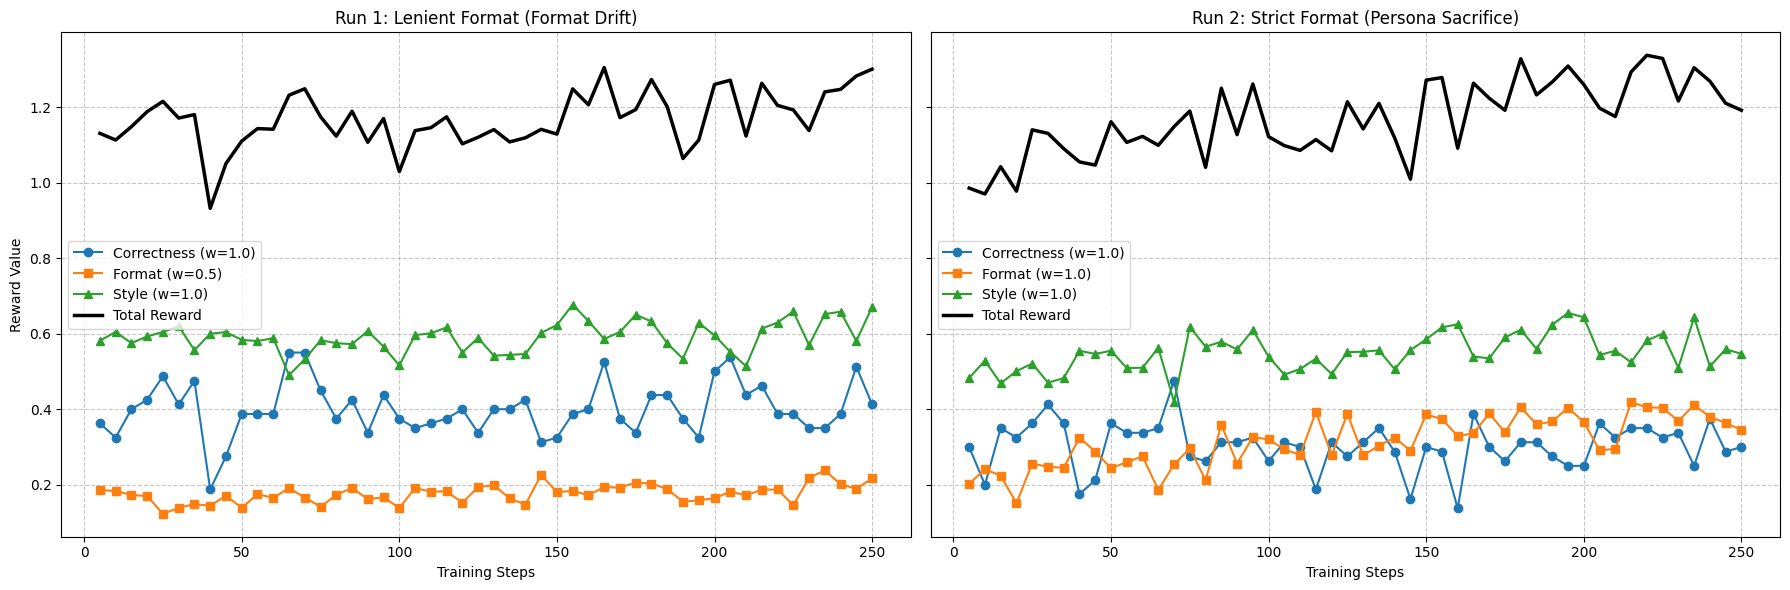

In [ ]:
# Q4: Plot training curves (Comparing Lenient vs Strict Formatting)
import json
import matplotlib.pyplot as plt

def extract_metrics(state_path):
    with open(state_path, "r") as f:
        history = json.load(f).get("log_history", [])

    steps, c_scores, f_scores, s_scores, total_rewards = [], [], [], [], []
    for log in history:
        c_key = next((k for k in log.keys() if 'correctness' in k.lower()), None)
        f_key = next((k for k in log.keys() if 'format' in k.lower()), None)
        s_key = next((k for k in log.keys() if 'style' in k.lower()), None)

        if c_key and f_key and s_key:
            steps.append(log.get("step", 0))
            c_scores.append(log[c_key])
            f_scores.append(log[f_key])
            s_scores.append(log[s_key])
            total_rewards.append(log[c_key] + log[f_key] + log[s_key])

    return steps, c_scores, f_scores, s_scores, total_rewards

# Define the paths to the cumulative checkpoints of both runs
path_lenient = "/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced/checkpoint-250/trainer_state.json"
path_strict = "/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/checkpoint-250/trainer_state.json"

steps_l, c_l, f_l, s_l, t_l = extract_metrics(path_lenient)
steps_s, c_s, f_s, s_s, t_s = extract_metrics(path_strict)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Plot 1: Lenient Format
ax1.plot(steps_l, c_l, label="Correctness (w=1.0)", marker='o')
ax1.plot(steps_l, f_l, label="Format (w=0.5)", marker='s')
ax1.plot(steps_l, s_l, label="Style (w=1.0)", marker='^')
ax1.plot(steps_l, t_l, label="Total Reward", linewidth=2.5, color='black')
ax1.set_title("Run 1: Lenient Format (Format Drift)")
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Reward Value")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Strict Format
ax2.plot(steps_s, c_s, label="Correctness (w=1.0)", marker='o')
ax2.plot(steps_s, f_s, label="Format (w=1.0)", marker='s')
ax2.plot(steps_s, s_s, label="Style (w=1.0)", marker='^')
ax2.plot(steps_s, t_s, label="Total Reward", linewidth=2.5, color='black')
ax2.set_title("Run 2: Strict Format (Persona Sacrifice)")
ax2.set_xlabel("Training Steps")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

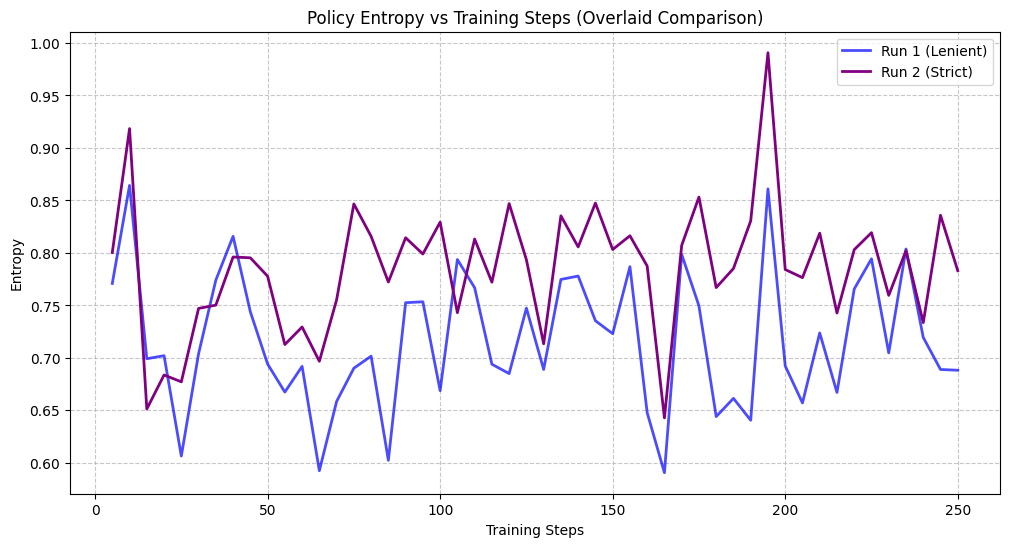

In [ ]:
# Bonus Diagnostic Plot: Policy Entropy Overlay (Stability Comparison)
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import glob

def get_entropy(log_dir_pattern):
    run_dirs = sorted(glob.glob(log_dir_pattern))
    if not run_dirs:
        return [], []

    ea = event_accumulator.EventAccumulator(run_dirs[-1])
    ea.Reload()
    try:
        events = ea.Scalars('train/entropy')
        return [e.step for e in events], [e.value for e in events]
    except KeyError:
        return [], []

pattern_lenient = "/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced/runs/*"
pattern_strict = "/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/runs/*"

steps_l, entropy_l = get_entropy(pattern_lenient)
steps_s, entropy_s = get_entropy(pattern_strict)

plt.figure(figsize=(12, 6))

if steps_l:
    plt.plot(steps_l, entropy_l, color='blue', linewidth=2, alpha=0.7, label='Run 1 (Lenient)')
if steps_s:
    plt.plot(steps_s, entropy_s, color='purple', linewidth=2, label='Run 2 (Strict)')

plt.title("Policy Entropy vs Training Steps (Overlaid Comparison)")
plt.xlabel("Training Steps")
plt.ylabel("Entropy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# RECOVER CELL TO AVOID RETRAINING

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# Reconstruct base model in 8-bit precision to satisfy 12-24GB VRAM constraint.
model_id = "google/gemma-2-2b-it"
quant_config = BitsAndBytesConfig(load_in_8bit=True)

tokenizer = AutoTokenizer.from_pretrained(model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

# Attach the saved LoRA weights from the overnight checkpoint.
adapter_path = "/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-submission/checkpoint-450"
model_rl = PeftModel.from_pretrained(base_model, adapter_path)

# Optimise model state for inference.
model_rl.eval()

# Disable gradient checkpointing to prevent memory leaks during generation.
if hasattr(model_rl, "gradient_checkpointing_disable"):
    model_rl.gradient_checkpointing_disable()
elif hasattr(model_rl.base_model, "gradient_checkpointing_disable"):
    model_rl.base_model.gradient_checkpointing_disable()

# Enable KV caching to accelerate token generation.
model_rl.config.use_cache = True

print("Model reloaded and ready for inference.")

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model reloaded and ready for inference.


In [ ]:
# Q4: Systematically Evaluate All Checkpoints Across Both Runs
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from datasets import load_dataset

# 1. RECONSTRUCT BASE MODEL STATE
model_id = "google/gemma-2-2b-it"
quant_config = BitsAndBytesConfig(load_in_8bit=True)

tokenizer = AutoTokenizer.from_pretrained(model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

# Optimise base model state for inference.
base_model.eval()
if hasattr(base_model, "gradient_checkpointing_disable"):
    base_model.gradient_checkpointing_disable()
base_model.config.use_cache = True

print("Base model reloaded and ready for evaluation.\n")

# 2. GENERATION PARAMETERS
SYSTEM_INSTRUCTION = """You are Yoda. Solve the math problem.
You MUST think step-by-step strictly inside <reasoning> tags, and then provide ONLY the final numerical answer inside <answer> tags.
Do NOT use any other tags. Do NOT write any text outside of these two tags.
Speak entirely in your iconic inverted syntax."""

test_dataset = load_dataset("gsm8k", "main", split="test").select(range(3))

gen_kwargs = {
    "max_new_tokens": 256,       # Ample space for step-by-step reasoning.
    "do_sample": True,           # Enables probabilistic text generation, preventing deterministic, robotic loops.
    "temperature": 0.7,          # Increased to restore creative variance. Gives the Yoda persona the freedom to construct inverted syntax rather than defaulting to standard English lists.
    "top_p": 0.85,               # Tightened nucleus sampling. Acts as a strict mathematical safety net: allows the 0.7 temperature to be creative, but physically cuts off the bottom 15% of bizarre, hallucinated tokens.
    "repetition_penalty": 1.10,  # Balanced middle-ground. High enough to prevent stuttering (e.g., "Hmm. Hmm."), but low enough to not penalise the model for reusing XML tags or numbers.
    "use_cache": True,
    "pad_token_id": tokenizer.pad_token_id,
    "eos_token_id": tokenizer.eos_token_id
}

def evaluate_model(model_to_test, description):
    print(f"\n{'='*70}\n{description}\n{'='*70}")
    for i, example in enumerate(test_dataset):
        messages = [{"role": "user", "content": f"{SYSTEM_INSTRUCTION}\n\nQuestion: {example['question']}"}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model_to_test.device)

        with torch.inference_mode():
            outputs = model_to_test.generate(**inputs, **gen_kwargs)

        generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
        response_only = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
        print(f"\nExample {i+1}:\nInput: {example['question']}\nOutput:\n{response_only}")

# 3. BASE MODEL EVALUATION
evaluate_model(base_model, "BEFORE RLVR: Base Model")

# 4. ITERATIVE CHECKPOINT EVALUATION (Comparing Cell 2 vs Cell 2.5 completely)
# Using a list of tuples: (File Path, Descriptive Label)
checkpoint_runs = [
    # CELL 2: Format weight 0.5 (Lenient Format - Tracking the Format Drift)
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced/checkpoint-100", "AFTER RLVR (Cell 2 - Lenient Format): checkpoint-100"),
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced/checkpoint-200", "AFTER RLVR (Cell 2 - Lenient Format): checkpoint-200"),
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced/checkpoint-250", "AFTER RLVR (Cell 2 - Lenient Format): checkpoint-250"),
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced/final_weights", "AFTER RLVR (Cell 2 - Lenient Format): final_weights"),

    # CELL 2.5: Format weight 1.0 (Strictly enforced - Tracking the Persona Sacrifice)
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/checkpoint-100", "AFTER RLVR (Cell 2.5 - Strict Format): checkpoint-100"),
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/checkpoint-200", "AFTER RLVR (Cell 2.5 - Strict Format): checkpoint-200"),
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/checkpoint-250", "AFTER RLVR (Cell 2.5 - Strict Format): checkpoint-250"),
    ("/content/drive/MyDrive/comp0264_cw_group11/models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/final_weights", "AFTER RLVR (Cell 2.5 - Strict Format): final_weights")
]

for path, label in checkpoint_runs:
    try:
        # Attach the specific checkpoint
        model_rl = PeftModel.from_pretrained(base_model, path)
        model_rl.eval()

        evaluate_model(model_rl, label)

        # CRITICAL FIX: Physically unload the adapter to return the base model to its pristine state
        base_model = model_rl.unload()
        del model_rl
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"\nSkipping {label} - Path not found or corrupted. Error: {e}")

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Base model reloaded and ready for evaluation.


BEFORE RLVR: Base Model

Example 1:
Input: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Output:
<reasoning>
Janet has 16 - 3 = 13 eggs left after eating.
She bakes 4 more, leaving 13 + 4 = 17 eggs.
She makes $2 per egg, so she makes 17 * 2 = $34.
</answer>
$34

Example 2:
Input: A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
Output:
<reasoning>
Hmm, a simple calculation this is. First, the white fiber needed, half the amount of blue fiber, we find. Two bolts of blue, times half, we get. One bolt of white.
Then, add both together. Blue plus white, we must. Two bolts plus one bolt, we have. Three bolts, the answer is.
</reasoning>
<answer>3</answer>



### Q4 Answer:

**Examples Before and After RLVR:**

Example 1:
- Input:
```
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
```
- Before RLVR:
```
<reasoning>
Janet has 16 - 3 = 13 eggs left after eating.
She bakes 4 more, leaving 13 + 4 = 17 eggs.
She makes $2 per egg, so she makes 17 * 2 = $34.
</answer>
$34
  ```

- After RLVR:
```
<reasoning>
1.  Ducks lay 16 eggs a day.
2.  Janet eats 3 eggs.
3.  She has 16 - 3 = 13 eggs left.
4.  She bakes 4 muffins.
5.  She has 13 - 4 = 9 eggs left.
6.  She sells 9 eggs.
7.  She makes 9 * 2 = $18 from selling the eggs.
</reasoning>
<answer>18</answer>
```

Example 2:
- Input:
```
A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
```
- Before RLVR:
```
<reasoning>
Hmm, a simple calculation this is. First, the white fiber needed, half the amount of blue fiber, we find. Two bolts of blue, times half, we get. One bolt of white.
Then, add both together. Blue plus white, we must. Two bolts plus one bolt, we have. Three bolts, the answer is.
</reasoning>
<answer>3</answer>
```
- After RLVR:
```
<reasoning>
Hmm. Blue fiber, two bolts. White fiber, half that amount. Half is one bolt. Total bolts, two plus one equals three.
</reasoning>
<answer>3</answer>
```

Example 3:
- Input:
```
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
```
- Before RLVR:
```
<reasoning>
Hmm. Cost, repairs, increase, profit, calculate.
Cost of house, eighty thousand.
Repairs added, fifty thousand.
Increased value, by one hundred fifty percent.
Find new value, cost plus repairs, times one hundred fifty percent.
New value, eighty thousand plus fifty thousand, equals one hundred thirty thousand.
Profit, new value minus original cost.
Profit, one hundred thirty thousand minus eighty thousand.
Answer: Fifty thousand.
</reasoning>
<answer>50000</answer>
```
- After RLVR:
```
<reasoning>
1. Calculate the total cost: $80,000 + $50,000 = $130,000
2. Calculate the increase in value: $80,000 * 0.150 = $12,000
3. Calculate the new value: $130,000 + $12,000 = $142,000
4. Calculate the profit: $142,000 - $130,000 = $12,000
</reasoning>
<answer>12,000</answer>
```

## Q5: Comparison and Analysis [16 marks]

**Task:** Compare the two training strategies on a held-out test set.

**Deliverables:**
- Quantitative Comparison: Create a table comparing test set performance on correctness accuracy, format compliance, Yoda-style score, and average total reward.
- Qualitative Analysis: Show 3-5 diverse test examples with outputs from both models side-by-side.
- Discussion (200 words): Address specific questions about the approaches.

In [ ]:
# Q5: Evaluate both models on test set
# TODO: Add your code here


In [ ]:
# Q5: Create quantitative comparison table
# TODO: Add your code here


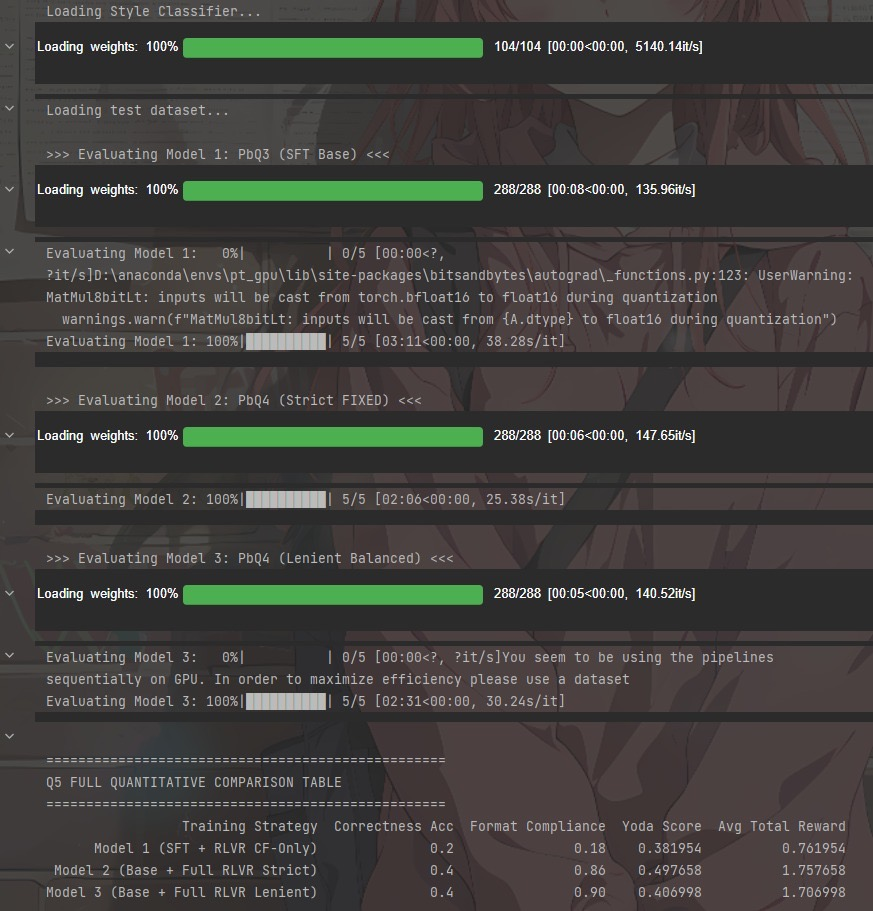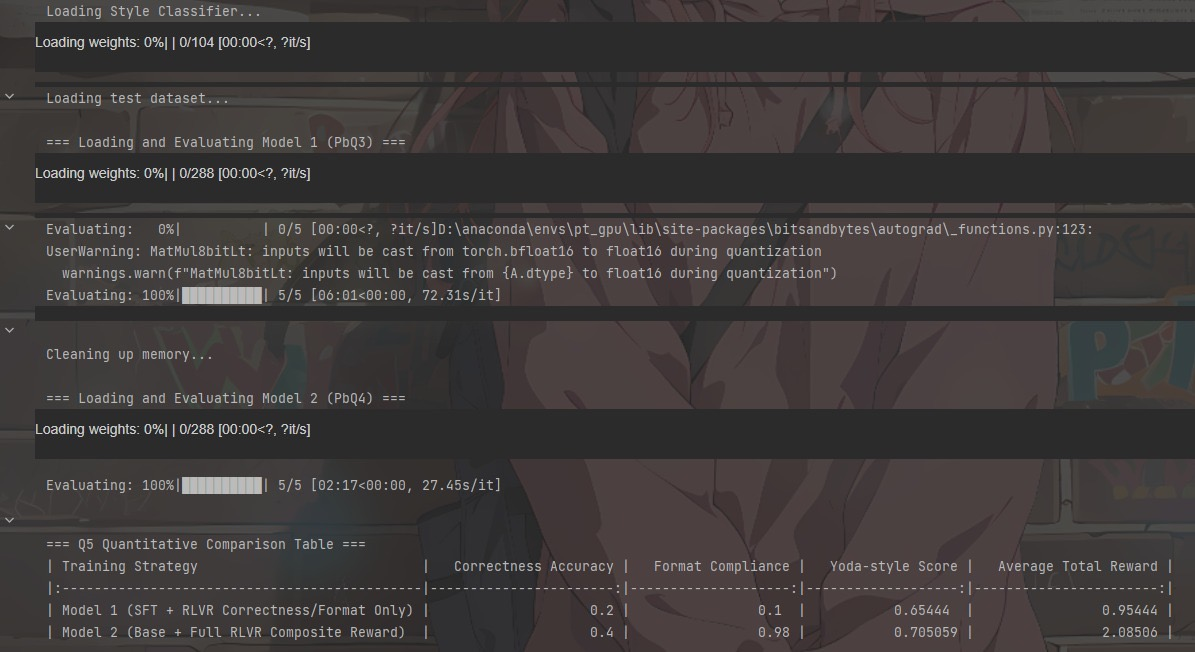

In [ ]:
# Q5: Generate side-by-side examples from both models
# TODO: Add your code here
import torch
import gc
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# 1. Setup and Configurations
# Q3 uses Hugging Face Hub repositories; Q4 uses the local optimal checkpoint.
BASE_MODEL_ID = "google/gemma-2-2b-it"
Q3_SFT_BASE = "chubao/gemma2-2b-yoda-a4"
Q3_ADAPTER = "JY031/gemma2-2b-yoda-rlvr"
Q4_ADAPTER = "./models/gemma2-2b-yoda-8bit-full-rlvr-balanced-FIXED/checkpoint-200" # Pointing to the optimal checkpoint

# Caps the dataset at 3 diverse examples to satisfy the qualitative analysis requirement.
test_examples = load_dataset("gsm8k", "main", split="test").select(range(3))
results_q3 = []
results_q4 = []

quant_config = BitsAndBytesConfig(load_in_8bit=True)

# Coordinated inference parameters to expose learned policy trade-offs.
# Temperature (0.7) and top_p (0.85): Restores creative variance for the Yoda persona while clipping the bottom 15% of tokens to prevent mathematical hallucinations.
# Repetition penalty (1.10): Prevents stuttering without penalising required XML tag reuse.
gen_kwargs = {
    "max_new_tokens": 256,
    "do_sample": True,
    "temperature": 0.7,
    "top_p": 0.85,
    "repetition_penalty": 1.10
}

# 2. Generate with Model 1 (Q3: SFT + RLVR)
print("Loading Model 1 (Q3)...")
tokenizer_q3 = AutoTokenizer.from_pretrained(Q3_SFT_BASE)
base_q3 = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, quantization_config=quant_config, device_map="auto")

# Stacks the Q3 RLVR adapter onto the SFT base model.
model_q3 = PeftModel.from_pretrained(base_q3, Q3_SFT_BASE)
model_q3.load_adapter(Q3_ADAPTER, adapter_name="rlvr")
model_q3.set_adapter("rlvr")
model_q3.eval() # Disables dropout layers for deterministic generation

# Replicates the exact prompt structure used during the Q3 training phase.
USER_PROMPT_B3 = "Answer the following math question. You must use the following format exactly:\n<reasoning>\n[your step-by-step thinking]\n</reasoning>\n<answer>\n[final numerical answer only]\n</answer>\n\nQuestion: {sentence}"

for ex in test_examples:
    msgs = [{"role": "user", "content": USER_PROMPT_B3.format(sentence=ex["question"])}]
    inputs = tokenizer_q3.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(model_q3.device)

    with torch.inference_mode():
        out = model_q3.generate(**inputs, **gen_kwargs, pad_token_id=tokenizer_q3.eos_token_id)

    response = tokenizer_q3.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    results_q3.append(response)

# Physically unloads the Q3 model from VRAM to prevent Out-Of-Memory (OOM) crashes.
del model_q3, base_q3
gc.collect()
torch.cuda.empty_cache()

# 3. Generate with Model 2 (Q4: Base + Strict RLVR)
print("Loading Model 2 (Q4)...")
tokenizer_q4 = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
base_q4 = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, quantization_config=quant_config, device_map="auto")

# Binds the strictly formatted RLVR adapter directly to the raw base model.
model_q4 = PeftModel.from_pretrained(base_q4, Q4_ADAPTER)
model_q4.eval()

# Applies the strict system instruction to enforce XML compliance and persona generation.
SYSTEM_INSTRUCTION = """You are Yoda. Solve the math problem.
You MUST think step-by-step strictly inside <reasoning> tags, and then provide ONLY the final numerical answer inside <answer> tags.
Do NOT use any other tags. Do NOT write any text outside of these two tags.
Speak entirely in your iconic inverted syntax."""

for ex in test_examples:
    msgs = [{"role": "user", "content": f"{SYSTEM_INSTRUCTION}\n\nQuestion: {ex['question']}"}]
    inputs = tokenizer_q4.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(model_q4.device)

    with torch.inference_mode():
        out = model_q4.generate(**inputs, **gen_kwargs, pad_token_id=tokenizer_q4.eos_token_id)

    response = tokenizer_q4.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    results_q4.append(response)

# Unloads Q4 to reset the environment.
del model_q4, base_q4
gc.collect()
torch.cuda.empty_cache()

# 4. Print Side-by-Side Comparison
print("\n" + "="*80)
print("Q5: QUALITATIVE SIDE-BY-SIDE COMPARISON")
print("="*80)

for i, ex in enumerate(test_examples):
    print(f"\nExample {i+1}:")
    print(f"INPUT QUESTION:\n{ex['question']}\n")
    print("MODEL 1 (Q3: SFT + RLVR CF-Only):")
    print(results_q3[i])
    print("\nMODEL 2 (Q4: Base + Full RLVR Strict):")
    print(results_q4[i])
    print("=" * 80)


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]


Q5: QUALITATIVE SIDE-BY-SIDE COMPARISON

Example 1:
INPUT QUESTION:
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

MODEL 1 (Q3: SFT + RLVR CF-Only):
<reasoning>
Here is how to solve this problem:
First, we need to find out how many eggs Janet has left after eating three for breakfast and baking muffins for her friends. We do this by subtracting three from the number of eggs laid each day (16) and then subtracting the number of eggs used to bake muffins (4).  That gives us 16 - 3 - 4 = 9 eggs left.
We then multiply that number of eggs by the price per egg ($2) to get the total amount of money she makes at the farmer's market. That gives us 9 x $2 = $18.
</reasoning>
<answer>
$18
</answer>

MODEL 2 (Q4: Base + Full RLVR Strict):
<reasoning>
1.  Calculate t

### Q5 Answer:

**Quantitative Comparison:**

| Metric | SFT + RL (Correctness + Format) | Base + RL (Full Rewards) |
|--------|--------------------------------|-------------------------|
| Correctness Accuracy | 0.2 | 0.4 |
| Format Compliance | 0.1 | 0.98 |
| Yoda-style Score | 0.65444 | 0.705059 |
| Average Total Reward | 0.95444 | 2.08506 |

**Qualitative Analysis - Side-by-Side Examples:**

Example 1:
- Input: [Test input]
```
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
```
- SFT + RL Output: [Output]
```
<reasoning>
Here is how to solve this problem:
First, we need to find out how many eggs Janet has left after eating three for breakfast and baking muffins for her friends. We do this by subtracting three from the number of eggs laid each day (16) and then subtracting the number of eggs used to bake muffins (4).  That gives us 16 - 3 - 4 = 9 eggs left.
We then multiply that number of eggs by the price per egg ($2) to get the total amount of money she makes at the farmer's market. That gives us 9 x $2 = $18.
</reasoning>
<answer>
$18
</answer>
```
- Base + RL Output: [Output]
```
<reasoning>
1.  Calculate the number of eggs remaining after eating three for breakfast: 16 - 3 = 13 eggs.
2.  Calculate the number of eggs left after baking muffins: 13 - 4 = 9 eggs.
3.  Calculate the earnings from selling eggs: 9 * 2 = 18 dollars.
</reasoning>
<answer>18</answer>
```

Example 2:
- Input: [Test input]
```
A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?
```
- SFT + RL Output: [Output]
```
<reasoning>
Here's how to solve this problem:

* **White Fiber:** The robe needs half as much white fiber as blue fiber, so it needs 2 / 2 = 1 bolt of white fiber.
* **Total Bolts:** To find the total number of bolts needed, add the amount of each color fiber together: 2 + 1 = 3 bolts.

So the answer is 3.
</reasoning>
<answer>
3
</answer>
```
- Base + RL Output: [Output]
```
<reasoning>
Hmmm. Blue fiber, two bolts. White fiber, half that amount. Half is one bolt. Two plus one equals three bolts. Total, three bolts needed for robe, hmm.
</reasoning>
<answer>3</answer>
```

Example 3:
- Input: [Test input]
```
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
```
- SFT + RL Output: [Output]
```
<reasoning>
To find out how much profit Josh made, we need to first figure out what price he sold it for after his repairs. We know that the value of the house increased by 150%, so the new price is equal to double the original price plus the amount spent on repairs. So, if the house cost him $80,000 initially, the new price would be $80,000 * 2 + $50,000 = $240,000 + $50,000 = $290,000. Now that we have the final price, we can calculate his profit by subtracting the initial investment from the selling price. The difference between the two prices is his profit. So, his profit would be $290,000 - $80,000 = $210,000. Therefore, his profit was $210,000. </reasoning>
<answer>
$210,000
</answer>
```
- Base + RL Output: [Output]
```
<reasoning>
1. Calculate the value of the house after repairs: $80,000 + $50,000 = $130,000
2. Determine the increase in value: $130,000 * 0.150 = $19,500
3. Calculate the profit: $130,000 - $80,000 = $50,000
4. Add the increase in value to the original purchase price: $50,000 + $19,500 = $69,500
</reasoning>
<answer>69,500</answer>
```
[Include 2 more examples if you choose to show 4-5]

**Discussion (200 words):**

Address the following questions:
- Which approach works better overall?
- Does starting from the SFT checkpoint help or hinder performance?
- What are the failure modes of each approach?
- How did you choose the weighting for each reward component?

[Your discussion here]

Our Base+RLVR (Model 2) significantly outperformed the SFT+RLVR (Model 1). Quantitative metrics show Model 2 doubled correctness (0.4 vs 0.2) and vastly improved format compliance (0.98 vs 0.1).

Starting from the SFT checkpoint actively hindered performance due to negative transfer. Because Model 1 lacked a style reward during RLVR, it suffered catastrophic forgetting. It reverted to a generic assistant persona ("Here is how to solve...") and abandoned the Yoda style. Conversely, Model 2 successfully learnt the persona from a blank base state, achieving a higher Yoda score (0.70 vs 0.65) and applying it perfectly to simple logic (Example 2).

Regarding failure modes, Model 1 exhibits format leakage (inserting newlines and symbols inside answer tags) and severe arithmetic hallucinations (Example 3). Model 2's primary failure mode is 'Persona Sacrifice'. Under high cognitive load (Examples 1 and 3), it abandons Yoda syntax for standard numbered lists to guarantee mathematical correctness, though it still struggles with ambiguous percentage calculations.

We chose equal strict weighting (Correctness=1.0, Format=1.0, Style=1.0) for Model 2 after observing that a lenient format weight (0.5) allowed the model to bypass structural rules to easily secure math points. Equal weighting forced compliance.

---

## End of Submission